# Reproduction and Methodological Extension of a Stacking-Based Ensemble for Heart Disease Prediction

**Selected Research Paper:**  
M. Bhagat, A. Sharma, and P. Agarwal, *“An Efficient Stacking-Based Ensemble Technique for Early Heart Attack Prediction,”* Multimedia Tools and Applications, 2025.  
https://doi.org/10.1007/s11042-024-19293-7

This notebook investigates the reproducibility and methodological robustness of the machine learning framework proposed by Bhagat *et al.* [1] for binary heart disease prediction. The original study evaluates six supervised learning algorithms which are Logistic Regression, Decision Tree, Random Forest, Extreme Gradient Boosting, Naive Bayes and K-Nearest Neighbours and subsequently combines their predictions through a stacking-based ensemble. The analysis is performed using a heart disease dataset containing 1,025 observations and 14 recorded attributes, with the central objective of determining whether an ensemble of heterogeneous classifiers can provide stronger predictive performance than the individual models.

The first part of this notebook focuses on reproducing the published methodology as closely as the available information permits. This involves verifying the dataset and feature structure, reconstructing the reported preprocessing procedure, implementing the six baseline classifiers, reproducing the five-fold stacking framework and evaluating the models using the performance measures reported by the authors. 

Where implementation details are not fully specified, necessary assumptions are documented explicitly so that differences between the reproduced and published results can be interpreted transparently.

The second part extends the reproduction into a critical machine learning investigation. Dataset characteristics, reproduced model behaviour and discrepancies from the published findings are examined to identify methodological limitations that may influence reliability or generalisation. A separate proposed approach is then developed and evaluated through a controlled experimental protocol, enabling comparison between the published findings, the reproduced baseline and the methodological extension.

The overall objective is therefore to assess not only whether the reported results can be reproduced, but also how robust and experimentally defensible the underlying machine learning pipeline is under systematic analysis.

## Experimental Environment and Reproducibility

A controlled and reproducible environment is used throughout this study so that differences between published and reproduced results can be interpreted consistently. The implementation uses `pandas` and `NumPy` for data handling, `scikit-learn` for preprocessing, classification and evaluation, `XGBoost` for gradient boosting, and `Matplotlib` for visualisation. A fixed random seed is applied wherever supported. Since the selected paper does not report its random seed or software configuration [1], these settings are treated as explicit reproduction assumptions.

In [10]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    matthews_corrcoef
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Dataset Loading and Structural Verification

The heart disease dataset used for the reproduction is loaded without modification so that its initial structure can be compared with the dataset described by Bhagat *et al.* [1]. The study reports 1,025 observations represented by 13 clinical predictors and one binary target attribute. Confirming the dataset dimensions, feature representation and data types at this stage establishes that subsequent experiments are being performed on a structurally consistent dataset before any preprocessing is introduced.

In [12]:
df = pd.read_csv("heart.csv")

print("Dataset Shape:", df.shape)
print("Column Names:")
print(df.columns.tolist())

display(df.head())

display(
    df.dtypes
      .rename("Data Type")
      .to_frame()
)

Dataset Shape: (1025, 14)
Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


,Data Type
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


### Structural Verification

The loaded dataset contains 1,025 observations and 14 attributes, matching the experimental structure reported by Bhagat *et al.* [1]. The variables correspond to 13 clinical predictors and a binary `target` attribute. All features are represented numerically, with `oldpeak` stored as a continuous floating-point variable while the remaining attributes use integer representations. Several clinically categorical variables are therefore already numerically coded, which will need to be considered when reconstructing the preprocessing procedure described in the study.

## Data Integrity and Distribution Audit

Before reconstructing the modelling pipeline, the dataset is examined for characteristics that may influence training and evaluation. Missing observations, target distribution, duplicate records and observed feature ranges are assessed together to establish the condition of the data prior to preprocessing. No records are altered during this stage, allowing the initial reproduction to remain separated from any later methodological changes motivated by the audit findings.

In [14]:
# Core data-quality checks
missing = df.isna().sum()
target_counts = df["target"].value_counts().sort_index()
target_pct = df["target"].value_counts(normalize=True).sort_index() * 100

print("Missing Values:")
display(missing.rename("Missing").to_frame())

print(f"Total missing values: {missing.sum()}")

print("Target Distribution:")
display(pd.DataFrame({
    "Count": target_counts,
    "Percentage (%)": target_pct.round(2)
}))

print(f"Exact duplicate rows: {df.duplicated().sum()}")
print(f"Unique rows: {len(df.drop_duplicates())}")

print("Observed Feature Ranges:")
display(pd.DataFrame({
    "Minimum": df.min(),
    "Maximum": df.max(),
    "Unique Values": df.nunique()
}))

Missing Values:


,Missing
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Total missing values: 0
Target Distribution:


,Count,Percentage (%)
target,,
0,499,48.68
1,526,51.32


Exact duplicate rows: 723
Unique rows: 302
Observed Feature Ranges:


,Minimum,Maximum,Unique Values
age,29.0,77.0,41
sex,0.0,1.0,2
cp,0.0,3.0,4
trestbps,94.0,200.0,49
chol,126.0,564.0,152
fbs,0.0,1.0,2
restecg,0.0,2.0,3
thalach,71.0,202.0,91
exang,0.0,1.0,2
oldpeak,0.0,6.2,40


### Data Integrity Findings

The dataset contains no missing values and is almost evenly distributed between the two target classes, with 499 observations labelled as no heart disease and 526 labelled as heart disease. Consequently, no missing-value imputation or class-balancing procedure is required for the supplied data at this stage. This is notable because the original study describes a linear-regression-based imputation procedure as part of its preprocessing methodology [1], although that procedure is not required by this dataset instance.

A more substantial characteristic is the presence of 723 exact duplicate records, leaving only 302 unique observations. These records are retained during the initial reproduction so that the published experimental setting is not altered, but their potential influence on model evaluation will be examined later as part of the methodological analysis. Most observed feature ranges correspond with those reported in the paper; however, `ca` reaches 4 rather than the reported maximum of 3, while `thal` includes 0 despite the paper describing a range of 1–3 [1].

## Data Preprocessing and Train - Test Partition

The published study describes missing-value treatment, categorical encoding and numerical normalization before model training [1]. The supplied dataset contains no missing observations, so imputation is not required, while categorical predictors are already represented using numerical codes and are retained in that form. Because the paper does not specify the normalization method, Min-Max scaling is adopted for the continuous clinical measurements as a documented reproduction assumption. The dataset is then divided into an inferred 80:20 train - test split, with scaling parameters learned exclusively from the training subset.

In [15]:
# Separate input variables(X) from  target(Y)
X = df.drop(columns="target")
y = df["target"]

# Clinical feature groups
continuous_features = [
    "age", "trestbps", "chol", "thalach", "oldpeak"
]

categorical_features = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

#Missing-value handling
missing_count = X.isna().sum().sum()

if missing_count == 0:
    print("No missing values detected; imputation not required.")
else:
    print(f"Missing values detected: {missing_count}")

# Categorical encoding
# Categorical attributes are already numerically encoded
categorical_numeric = all(
    pd.api.types.is_numeric_dtype(X[col])
    for col in categorical_features
)

print(
    "Categorical encoding:",
    "Already numerically encoded; no additional transformation required."
    if categorical_numeric
    else "Additional encoding required."
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Min-Max normalization
scaler = MinMaxScaler()

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

X_train_processed[continuous_features] = scaler.fit_transform(
    X_train[continuous_features]
)

X_test_processed[continuous_features] = scaler.transform(
    X_test[continuous_features]
)

print(f"Training set: {X_train_processed.shape}")
print(f"Testing set:  {X_test_processed.shape}")

print("Scaled training-feature ranges:")
display(
    X_train_processed[continuous_features]
    .agg(["min", "max"])
    .T
)

print("Training target distribution:")
display(
    y_train.value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

print("Testing target distribution:")
display(
    y_test.value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

No missing values detected; imputation not required.
Categorical encoding: Already numerically encoded; no additional transformation required.
Training set: (820, 13)
Testing set:  (205, 13)
Scaled training-feature ranges:


,min,max
age,0.0,1.0
trestbps,0.0,1.0
chol,0.0,1.0
thalach,0.0,1.0
oldpeak,0.0,1.0


Training target distribution:


,Count
target,
0,397
1,423


Testing target distribution:


,Count
target,
0,102
1,103


### Preprocessing Outcome

The preprocessing stage produced 820 training observations and 205 testing observations, consistent with the inferred 80:20 partition used for this reproduction. No imputation or additional categorical encoding was required because the supplied dataset contains no missing values and its categorical attributes are already numerically represented. Min-Max normalization successfully mapped each selected continuous predictor to the range `[0, 1]` within the training data. Both subsets also retain an approximately even class distribution, reducing the likelihood that subsequent classifier comparisons will be dominated by class imbalance.

## Training of the Individual Classifiers

The six classification algorithms investigated in the original study are now trained using the reproduced training subset. Where the paper provides methodological guidance, it is retained; for example, the Decision Tree uses entropy as its splitting criterion [1]. However, the study does not report complete numerical hyperparameter configurations for the individual classifiers. Conventional baseline settings are therefore adopted for unspecified parameters and documented as reproduction assumptions rather than being optimised against the reported results.

In [26]:
# Paper-aligned baseline classifier configurations
paper_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="euclidean"
    )
}


# Train all six classifiers
fitted_models = {}

for name, model in paper_models.items():
    model.fit(X_train_processed, y_train)
    fitted_models[name] = model
    print(f"{name}: trained")


Logistic Regression: trained
Decision Tree: trained
Random Forest: trained
XGBoost: trained
Naive Bayes: trained
KNN: trained


## Evaluation of the Individual Classifiers

Each trained classifier is now evaluated on the held-out test subset that was not used during model fitting. To maintain direct comparability with the selected study, performance is assessed using Accuracy, Precision, Recall, F1-score and Area Under the ROC Curve (AUC) [1]. Predictions and class probabilities are retained for subsequent confusion-matrix and ROC analysis. This stage establishes the reproduced performance of the six individual classifiers before the stacking ensemble is constructed.

In [27]:
individual_results = []
individual_predictions = {}
individual_probabilities = {}

for name, model in fitted_models.items():

    # Generate class predictions and positive-class probabilities
    y_pred = model.predict(X_test_processed)
    y_prob = model.predict_proba(X_test_processed)[:, 1]

    # Store outputs for later confusion-matrix and ROC analysis
    individual_predictions[name] = y_pred
    individual_probabilities[name] = y_prob

    # Confusion-matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    mcc = matthews_corrcoef(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    individual_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Recall": recall,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc,
        "AUC": auc
    })


individual_results_df = pd.DataFrame(individual_results)

display(
    individual_results_df.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Logistic Regression,0.8000,0.8145,0.8738,0.7627,0.8738,0.7255,0.6062,0.8858
1,Decision Tree,0.9854,0.9852,0.9709,1.0000,0.9709,1.0000,0.9712,0.9854
2,Random Forest,0.9854,0.9852,0.9709,1.0000,0.9709,1.0000,0.9712,1.0000
3,XGBoost,0.9854,0.9852,0.9709,1.0000,0.9709,1.0000,0.9712,0.9894
4,Naive Bayes,0.8000,0.8178,0.8932,0.7541,0.8932,0.7059,0.6102,0.8706
5,KNN,0.8585,0.8626,0.8835,0.8426,0.8835,0.8333,0.7179,0.9628


### Individual Classifier Evaluation Outcome

The reproduced classifiers demonstrate substantial variation in test performance. Logistic Regression and Naive Bayes achieved accuracies of 80.00%, whereas Decision Tree, Random Forest and XGBoost each reached 98.54%. KNN achieved 85.85% accuracy, exactly matching the value reported by the original study [1], although its remaining evaluation metrics differ moderately from the published results.

The identical threshold-based performance of Decision Tree, Random Forest and XGBoost indicates that these models produced highly similar class predictions on the held-out subset, despite differences in their AUC values. Their substantially higher accuracies than those reported in the paper indicate that exact reproduction remains sensitive to experimental details not fully specified by the authors. These discrepancies are retained for subsequent reproducibility and methodological analysis rather than being corrected through result-driven parameter adjustment.

## Comparison with the Published Individual Classifier Results

The reproduced performance of the six individual classifiers is now compared directly with the values reported in the original study [1]. The comparison considers the complete set of reported evaluation measures rather than accuracy alone, allowing both numerical agreement and broader behavioural consistency between classifiers to be examined. Differences are retained as observed rather than adjusting model configurations retrospectively to reproduce the published results.

In [28]:
# Published results reported in Table 11 of the original study
published_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Naive Bayes",
        "KNN"
    ],

    "Accuracy": [
        0.8439,
        0.9268,
        0.9268,
        0.9073,
        0.8439,
        0.8585
    ],

    "F1-Score": [
        0.8620,
        0.9289,
        0.9333,
        0.9132,
        0.8608,
        0.8687
    ],

    "Recall": [
        0.9090,
        0.8909,
        0.9545,
        0.9090,
        0.9000,
        0.8727
    ],

    "Precision": [
        0.8196,
        0.9702,
        0.9130,
        0.9174,
        0.8250,
        0.8648
    ],

    "Sensitivity": [
        0.8439,
        0.9268,
        0.9268,
        0.9073,
        0.8439,
        0.8585
    ],

    "Specificity": [
        0.8620,
        0.9289,
        0.9333,
        0.9132,
        0.8608,
        0.8687
    ],

    "MCC": [
        0.8196,
        0.9702,
        0.9130,
        0.9174,
        0.8250,
        0.8648
    ],

    "AUC": [
        0.9204,
        0.9702,
        0.9734,
        0.9830,
        0.9185,
        0.9304
    ]
})


# Align published and reproduced results by model
published_comparison = published_results.set_index("Model")

reproduced_comparison = (
    individual_results_df
    .set_index("Model")
    .loc[published_comparison.index]
)


# Create comparison table
comparison_table = pd.DataFrame(index=published_comparison.index)

metrics = [
    "Accuracy",
    "F1-Score",
    "Recall",
    "Precision",
    "Sensitivity",
    "Specificity",
    "MCC",
    "AUC"
]

for metric in metrics:
    comparison_table[f"{metric} - Published"] = published_comparison[metric]
    comparison_table[f"{metric} - Reproduced"] = reproduced_comparison[metric]


comparison_table = comparison_table.reset_index()

display(
    comparison_table.style.format(
        {
            column: "{:.4f}"
            for column in comparison_table.columns
            if column != "Model"
        }
    )
)

,Model,Accuracy - Published,Accuracy - Reproduced,F1-Score - Published,F1-Score - Reproduced,Recall - Published,Recall - Reproduced,Precision - Published,Precision - Reproduced,Sensitivity - Published,Sensitivity - Reproduced,Specificity - Published,Specificity - Reproduced,MCC - Published,MCC - Reproduced,AUC - Published,AUC - Reproduced
0,Logistic Regression,0.8439,0.8000,0.8620,0.8145,0.9090,0.8738,0.8196,0.7627,0.8439,0.8738,0.8620,0.7255,0.8196,0.6062,0.9204,0.8858
1,Decision Tree,0.9268,0.9854,0.9289,0.9852,0.8909,0.9709,0.9702,1.0000,0.9268,0.9709,0.9289,1.0000,0.9702,0.9712,0.9702,0.9854
2,Random Forest,0.9268,0.9854,0.9333,0.9852,0.9545,0.9709,0.9130,1.0000,0.9268,0.9709,0.9333,1.0000,0.9130,0.9712,0.9734,1.0000
3,XGBoost,0.9073,0.9854,0.9132,0.9852,0.9090,0.9709,0.9174,1.0000,0.9073,0.9709,0.9132,1.0000,0.9174,0.9712,0.9830,0.9894
4,Naive Bayes,0.8439,0.8000,0.8608,0.8178,0.9000,0.8932,0.8250,0.7541,0.8439,0.8932,0.8608,0.7059,0.8250,0.6102,0.9185,0.8706
5,KNN,0.8585,0.8585,0.8687,0.8626,0.8727,0.8835,0.8648,0.8426,0.8585,0.8835,0.8687,0.8333,0.8648,0.7179,0.9304,0.9628


### Published and Reproduced Performance Comparison

The reproduced results show incomplete numerical agreement with the original study, but a clear similarity in the overall classifier behaviour is preserved. 

In both experiments, Logistic Regression and Naive Bayes form the weakest-performing group and achieve identical accuracies within their respective evaluations. Likewise, Decision Tree and Random Forest achieve equal accuracies in both the published and reproduced results and remain among the strongest individual classifiers. KNN retains an intermediate position and reproduces the published accuracy exactly at 85.85%.

The largest discrepancies occur for the tree-based and boosting models. Decision Tree and Random Forest increase from the published 92.68% to 98.54%, while XGBoost increases from 90.73% to 98.54%. Logistic Regression and Naive Bayes are reproduced approximately four percentage points below their reported accuracies. Despite these differences, the broad ranking and grouping of model performance remains similar, providing partial evidence that the behaviour of the original experimental pipeline has been reproduced.

Differences are also present across F1-score, recall, precision, MCC and AUC, indicating that agreement cannot be assessed from accuracy alone. These discrepancies are retained for later analysis of undocumented classifier configurations, data partitioning and dataset characteristics rather than being removed through retrospective parameter adjustment.

## Confusion Matrix Analysis of the Individual Classifiers

Confusion matrices are examined for each reproduced classifier to provide a class-level view of predictive performance beyond aggregate evaluation metrics. They distinguish correctly classified heart-disease and non-disease observations from false-positive and false-negative predictions, allowing differences in model error behaviour to be identified. The original study similarly presents confusion matrices for its six individual classifiers [1]. The predictions generated during the held-out evaluation are reused here without retraining or modifying any model.

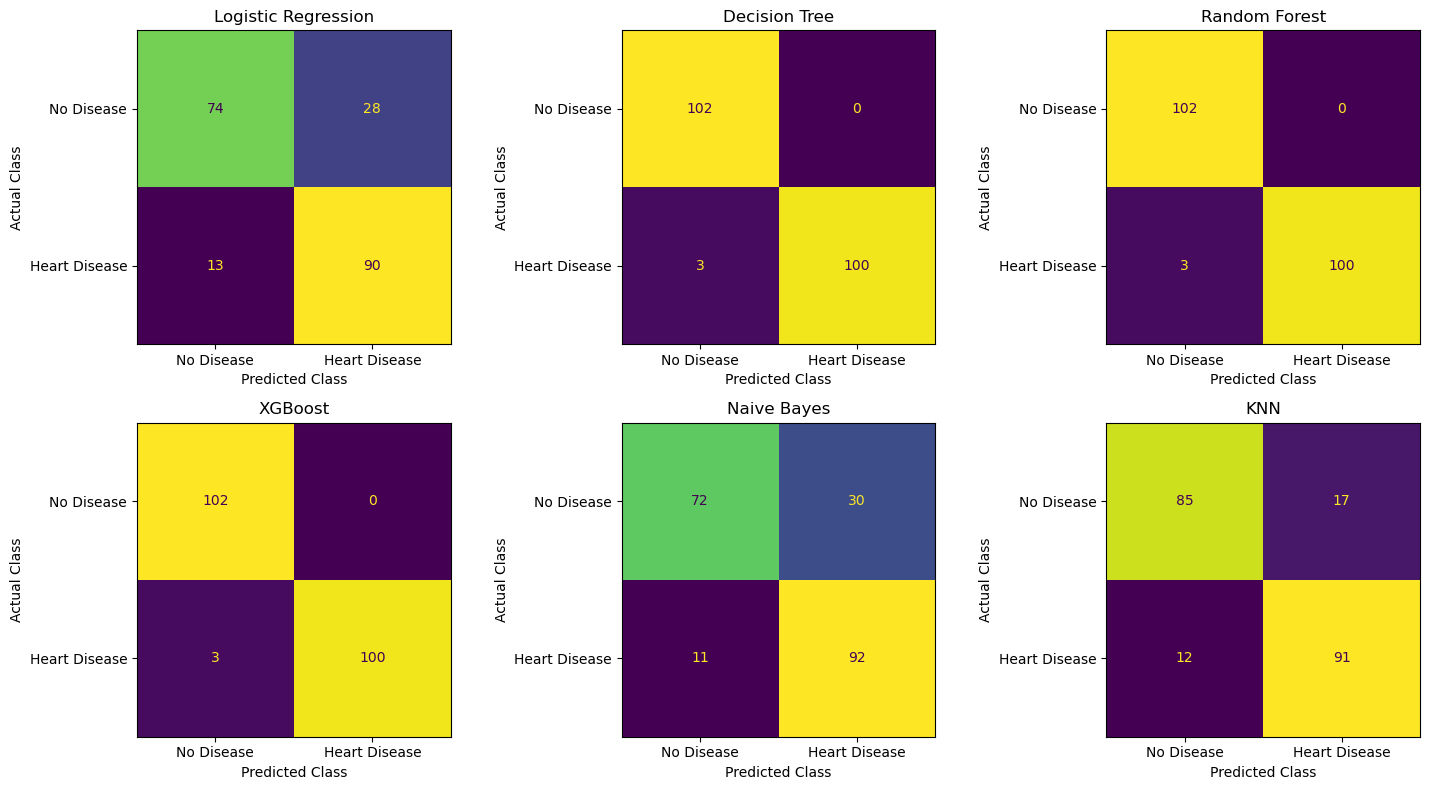

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

model_order = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost",
    "Naive Bayes",
    "KNN"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 8)
)

axes = axes.ravel()

for ax, name in zip(axes, model_order):

    y_pred = individual_predictions[name]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "No Disease",
            "Heart Disease"
        ]
    )

    disp.plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

### Confusion Matrix Evaluation

The confusion matrices reinforce the differences observed in the numerical evaluation. Logistic Regression produced 28 false positives and 13 false negatives, while Naive Bayes produced 30 false positives and 11 false negatives. KNN reduced these errors to 17 false positives and 12 false negatives. In contrast, Decision Tree, Random Forest and XGBoost produced identical class predictions, correctly identifying all 102 non-disease cases and 100 of the 103 heart-disease cases, with only three false negatives and no false positives. This explains their identical accuracy, precision, recall, F1-score, sensitivity, specificity and MCC values, despite differing AUC scores.

## ROC Curve Analysis of the Individual Classifiers

Receiver Operating Characteristic (ROC) curves are used to examine each classifier's ability to distinguish between heart-disease and non-disease observations across different classification thresholds. The corresponding Area Under the Curve (AUC) provides a threshold-independent measure of discriminatory performance. The original study also reports ROC curves and AUC values for the individual classifiers [Table 11]. The probability estimates generated during the held-out evaluation are reused here so that no models are retrained or modified.

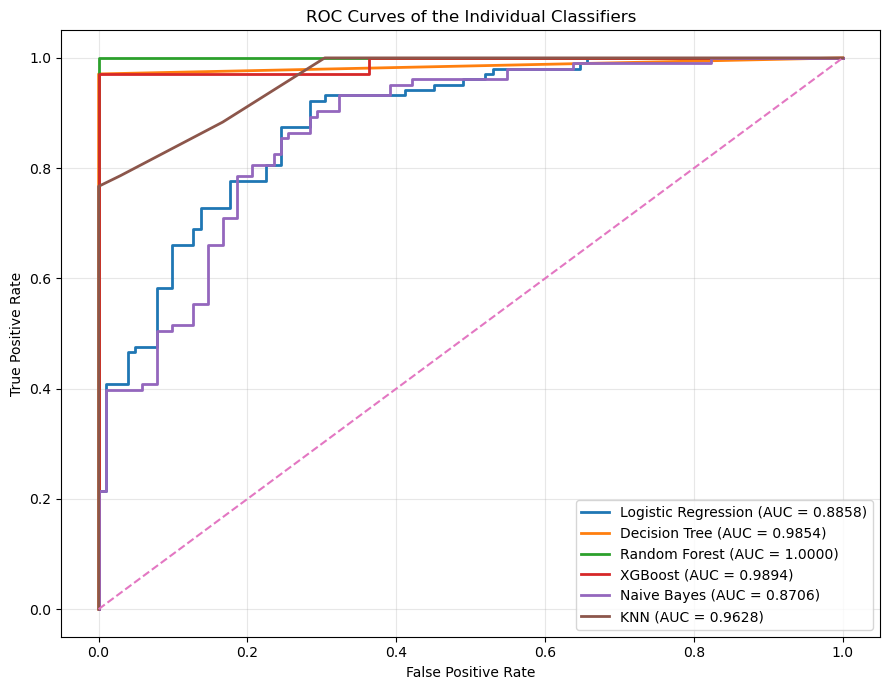

In [31]:
plt.figure(figsize=(9, 7))

for name in model_order:

    y_prob = individual_probabilities[name]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

# Random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves of the Individual Classifiers")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### ROC Curve Evaluation

The ROC analysis further separates the discriminatory behaviour of the reproduced classifiers. Random Forest achieved an AUC of 1.0000, indicating perfect ranking of positive and negative observations on the held-out subset, while XGBoost and Decision Tree also demonstrated very strong discrimination with AUC values of 0.9894 and 0.9854, respectively. KNN achieved an AUC of 0.9628, whereas Logistic Regression and Naive Bayes produced comparatively lower values of 0.8858 and 0.8706.

Although Decision Tree, Random Forest and XGBoost produced identical class predictions at the selected decision threshold, their ROC curves differ because AUC evaluates the ordering of predicted probabilities across all possible thresholds rather than only the final binary classifications. The strong separation achieved by the tree-based models is consistent with their superior held-out accuracy observed earlier.

## Five-Fold Stacking Ensemble

The individual classifiers are now combined using the five-fold stacking strategy proposed in the original study. During stacking, each base classifier generates out-of-fold probability estimates across the training data, which are subsequently used as inputs to a meta-classifier. The paper specifies a five-fold stacking procedure but does not provide a complete configuration for the final meta-classifier. Logistic Regression is therefore adopted as a conventional and transparent meta-classification assumption. The held-out test subset remains excluded from ensemble construction.

In [33]:
from sklearn.base import clone

# Five-fold CV used to generate out-of-fold predictions
stacking_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Each base model contains its own preprocessing pipeline so that
# scaling is learned independently inside the stacking folds
stacking_estimators = [
    (
        "lr",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", LogisticRegression(max_iter=2000))
        ])
    ),

    (
        "dt",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", DecisionTreeClassifier(
                criterion="entropy",
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "rf",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "xgb",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "nb",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", GaussianNB())
        ])
    ),

    (
        "knn",
        Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform",
                metric="euclidean"
            ))
        ])
    )
]

stacking_model = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=stacking_cv,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=-1
)

stacking_model.fit(X_train, y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,LogisticRegre...max_iter=2000)
,cv,StratifiedKFo... shuffle=True)
,stack_method,'predict_proba'
,n_jobs,-1
,passthrough,False
,verbose,0
,transformers,"[('continuous', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None


## Evaluation of the Five-Fold Stacking Ensemble

The trained stacking ensemble is now evaluated on the held-out test subset using the same performance measures applied to the individual classifiers. Accuracy, F1-score, Recall, Precision, Sensitivity, Specificity, MCC and AUC are calculated to maintain consistency with the evaluation framework reported in the original study. The test subset has remained excluded from both base-model fitting and meta-classifier construction, allowing the final ensemble to be assessed independently before comparison with the published stacking results.

In [34]:
# Generate stacking predictions on the untouched test subset
stacking_pred = stacking_model.predict(X_test)
stacking_prob = stacking_model.predict_proba(X_test)[:, 1]

# Confusion-matrix components
tn, fp, fn, tp = confusion_matrix(
    y_test,
    stacking_pred
).ravel()

# Calculate complete evaluation metrics
stacking_accuracy = accuracy_score(y_test, stacking_pred)
stacking_f1 = f1_score(y_test, stacking_pred)
stacking_recall = recall_score(y_test, stacking_pred)
stacking_precision = precision_score(y_test, stacking_pred)

stacking_sensitivity = tp / (tp + fn)
stacking_specificity = tn / (tn + fp)

stacking_mcc = matthews_corrcoef(
    y_test,
    stacking_pred
)

stacking_auc = roc_auc_score(
    y_test,
    stacking_prob
)

# Store results
stacking_results_df = pd.DataFrame({
    "Model": ["Five-Fold Stacking"],
    "Accuracy": [stacking_accuracy],
    "F1-Score": [stacking_f1],
    "Recall": [stacking_recall],
    "Precision": [stacking_precision],
    "Sensitivity": [stacking_sensitivity],
    "Specificity": [stacking_specificity],
    "MCC": [stacking_mcc],
    "AUC": [stacking_auc]
})

display(
    stacking_results_df.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Five-Fold Stacking,0.9854,0.9852,0.9709,1.0000,0.9709,1.0000,0.9712,1.0000


## Comparison with the Published Stacking Ensemble

The reproduced five-fold stacking ensemble is compared directly with the proposed ensemble reported in the original study [1]. The comparison uses the same evaluation measures considered previously for the individual classifiers. This provides a direct assessment of whether the central contribution of the paper can be reproduced under the documented experimental assumptions.

In [35]:
published_stacking = pd.DataFrame({
    "Model": ["Five-Fold Stacking"],
    "Accuracy": [0.9853],
    "F1-Score": [0.9861],
    "Recall": [0.9727],
    "Precision": [1.0000],
    "Sensitivity": [0.9853],
    "Specificity": [0.9861],
    "MCC": [1.0000],
    "AUC": [0.9880]
})

stacking_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "F1-Score",
        "Recall",
        "Precision",
        "Sensitivity",
        "Specificity",
        "MCC",
        "AUC"
    ],

    "Published": [
        published_stacking.loc[0, "Accuracy"],
        published_stacking.loc[0, "F1-Score"],
        published_stacking.loc[0, "Recall"],
        published_stacking.loc[0, "Precision"],
        published_stacking.loc[0, "Sensitivity"],
        published_stacking.loc[0, "Specificity"],
        published_stacking.loc[0, "MCC"],
        published_stacking.loc[0, "AUC"]
    ],

    "Reproduced": [
        stacking_results_df.loc[0, "Accuracy"],
        stacking_results_df.loc[0, "F1-Score"],
        stacking_results_df.loc[0, "Recall"],
        stacking_results_df.loc[0, "Precision"],
        stacking_results_df.loc[0, "Sensitivity"],
        stacking_results_df.loc[0, "Specificity"],
        stacking_results_df.loc[0, "MCC"],
        stacking_results_df.loc[0, "AUC"]
    ]
})

stacking_comparison["Difference"] = (
    stacking_comparison["Reproduced"]
    - stacking_comparison["Published"]
)

display(
    stacking_comparison.style.format({
        "Published": "{:.4f}",
        "Reproduced": "{:.4f}",
        "Difference": "{:+.4f}"
    })
)

,Metric,Published,Reproduced,Difference
0,Accuracy,0.9853,0.9854,+0.0001
1,F1-Score,0.9861,0.9852,-0.0009
2,Recall,0.9727,0.9709,-0.0018
3,Precision,1.0000,1.0000,+0.0000
4,Sensitivity,0.9853,0.9709,-0.0144
5,Specificity,0.9861,1.0000,+0.0139
6,MCC,1.0000,0.9712,-0.0288
7,AUC,0.9880,1.0000,+0.0120


### Stacking Reproduction Evaluation

The proposed ensemble was reproduced with very close agreement in its principal performance measure. The reproduced stacking model achieved 98.54% accuracy compared with the published 98.53%, a difference of only 0.01 percentage points. Precision was reproduced exactly at 1.0000, while F1-score and recall also remained closely aligned with the reported values. The reproduced AUC increased from the published 0.9880 to 1.0000.

This represents substantially stronger numerical agreement than was obtained for several of the individual classifiers and provides strong evidence that the central stacking result of the study can be reproduced under the adopted experimental assumptions. Differences in Sensitivity, Specificity and MCC are retained for later critical analysis, particularly because the corresponding columns in the published results exhibit apparent internal inconsistencies.

## Confusion Matrix Analysis of the Stacking Ensemble

The class-level behaviour of the reproduced five-fold stacking ensemble is examined using its confusion matrix. This analysis identifies the numbers of true positives, true negatives, false positives and false negatives produced on the held-out test subset. The original study similarly presents a confusion matrix for its proposed stacking technique [1]. The predictions generated during the preceding ensemble evaluation are reused without retraining or modifying the model.

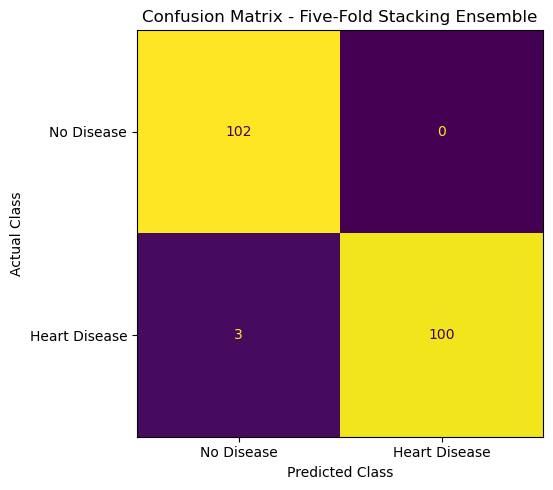

In [36]:
stacking_cm = confusion_matrix(
    y_test,
    stacking_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=stacking_cm,
    display_labels=[
        "No Disease",
        "Heart Disease"
    ]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    colorbar=False,
    values_format="d"
)

ax.set_title("Confusion Matrix - Five-Fold Stacking Ensemble")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

### Stacking Confusion Matrix Evaluation

The stacking ensemble correctly classified all 102 non-disease observations and 100 of the 103 heart-disease observations. No false-positive predictions were produced, while only three heart-disease cases were incorrectly classified as non-disease. This corresponds to the reproduced precision and specificity of 1.0000 and explains the overall accuracy of 98.54%. The remaining three false negatives account for the recall and sensitivity of 97.09%. Overall, the confusion matrix demonstrates highly consistent class-level performance while also showing that the ensemble's residual errors occur exclusively within the positive class.

## Comparative ROC Analysis of the Individual Classifiers and Stacking Ensemble

The ROC performance of the reproduced five-fold stacking ensemble is compared with all six individual classifiers on the same held-out test subset. Plotting the models together provides a direct assessment of their discriminatory ability across classification thresholds and shows whether stacking improves upon the individual classifiers. The corresponding AUC values are included for each model to support quantitative comparison with the ROC-based analysis presented in the original study [1].

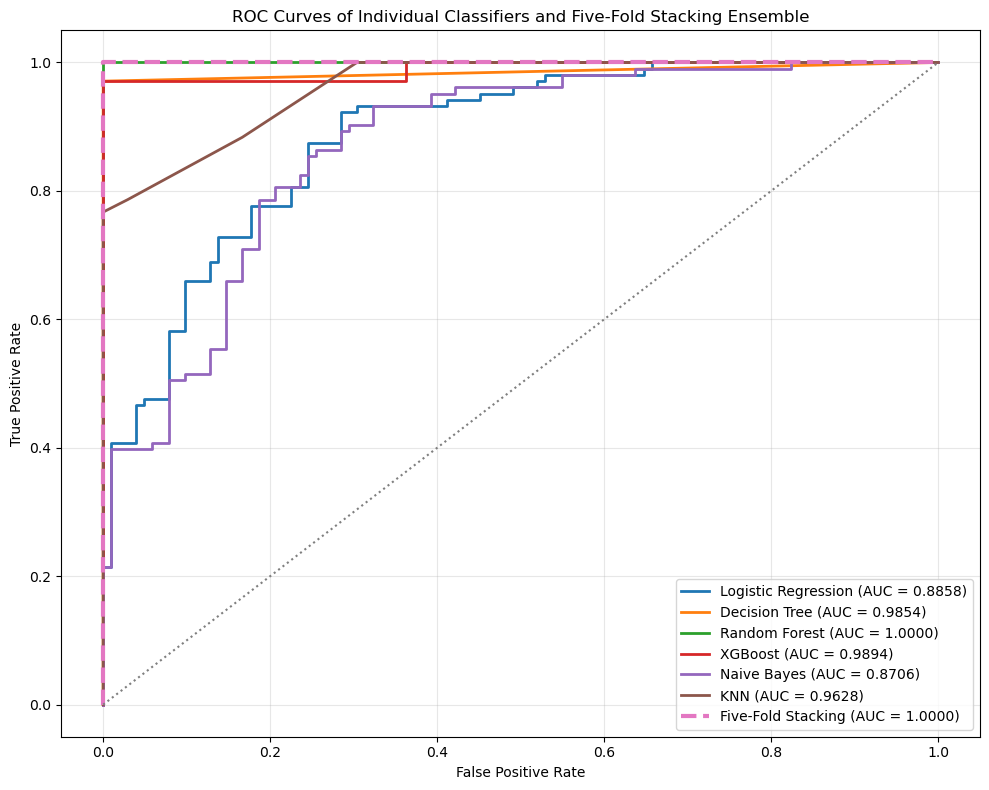

In [39]:
plt.figure(figsize=(10, 8))

# ROC curves for the six individual classifiers
for name in model_order:

    y_prob = individual_probabilities[name]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.4f})"
    )


# ROC curve for the five-fold stacking ensemble
stacking_fpr, stacking_tpr, _ = roc_curve(
    y_test,
    stacking_prob
)

plt.plot(
    stacking_fpr,
    stacking_tpr,
    linewidth=3,
    linestyle="--",
    label=f"Five-Fold Stacking (AUC = {stacking_auc:.4f})"
)


# Random-classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves of Individual Classifiers and Five-Fold Stacking Ensemble"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comparative ROC Evaluation

The combined ROC analysis demonstrates strong discrimination from the tree-based classifiers and the stacking ensemble. Random Forest and the five-fold stacking model both achieved an AUC of 1.0000, followed by XGBoost at 0.9894, Decision Tree at 0.9854 and KNN at 0.9628. Logistic Regression and Naive Bayes produced comparatively lower AUC values of 0.8858 and 0.8706, respectively.

Although stacking does not exceed Random Forest in reproduced AUC, it achieves the maximum possible value and improves upon most individual classifiers. This differs slightly from the original study, where the proposed stacking ensemble reported the highest AUC of 0.9880 [1]. The reproduced results therefore retain the strong discriminatory behaviour of the proposed ensemble while revealing differences in the relative performance of individual models.

## Overall Reproduction Summary

The complete reproduction is consolidated by comparing the principal performance of all six individual classifiers and the five-fold stacking ensemble with the corresponding published results. Accuracy and AUC are used here as compact summary measures because the complete metric-level comparisons have already been presented in the preceding sections. This final overview provides a direct view of numerical reproducibility and relative classifier behaviour before the remaining discrepancies and methodological limitations are investigated.

In [40]:
# Published headline results
published_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "Naive Bayes",
        "KNN",
        "Five-Fold Stacking"
    ],

    "Published Accuracy": [
        0.8439,
        0.9268,
        0.9268,
        0.9073,
        0.8439,
        0.8585,
        0.9853
    ],

    "Published AUC": [
        0.9204,
        0.9702,
        0.9734,
        0.9830,
        0.9185,
        0.9304,
        0.9880
    ]
})


# Combine reproduced individual and stacking results
reproduced_summary = pd.concat([
    individual_results_df[[
        "Model",
        "Accuracy",
        "AUC"
    ]],

    stacking_results_df[[
        "Model",
        "Accuracy",
        "AUC"
    ]]
], ignore_index=True)

reproduced_summary = reproduced_summary.rename(columns={
    "Accuracy": "Reproduced Accuracy",
    "AUC": "Reproduced AUC"
})


# Merge published and reproduced results
overall_summary = published_summary.merge(
    reproduced_summary,
    on="Model"
)

# Calculate numerical differences
overall_summary["Accuracy Difference"] = (
    overall_summary["Reproduced Accuracy"]
    - overall_summary["Published Accuracy"]
)

overall_summary["AUC Difference"] = (
    overall_summary["Reproduced AUC"]
    - overall_summary["Published AUC"]
)


display(
    overall_summary.style.format({
        "Published Accuracy": "{:.4f}",
        "Reproduced Accuracy": "{:.4f}",
        "Accuracy Difference": "{:+.4f}",
        "Published AUC": "{:.4f}",
        "Reproduced AUC": "{:.4f}",
        "AUC Difference": "{:+.4f}"
    })
)

,Model,Published Accuracy,Published AUC,Reproduced Accuracy,Reproduced AUC,Accuracy Difference,AUC Difference
0,Logistic Regression,0.8439,0.9204,0.8000,0.8858,-0.0439,-0.0346
1,Decision Tree,0.9268,0.9702,0.9854,0.9854,+0.0586,+0.0152
2,Random Forest,0.9268,0.9734,0.9854,1.0000,+0.0586,+0.0266
3,XGBoost,0.9073,0.9830,0.9854,0.9894,+0.0781,+0.0064
4,Naive Bayes,0.8439,0.9185,0.8000,0.8706,-0.0439,-0.0479
5,KNN,0.8585,0.9304,0.8585,0.9628,+0.0000,+0.0324
6,Five-Fold Stacking,0.9853,0.9880,0.9854,1.0000,+0.0001,+0.0120


### Overall Evaluation of the Paper Reproduction

The reproduction achieved strong agreement with the central finding of the original study while revealing important discrepancies at the individual-classifier level. Logistic Regression and Naive Bayes produced reproduced accuracies of 80.00%, compared with 84.39% for both models in the published results, corresponding to decreases of 4.39 percentage points. In contrast, Decision Tree and Random Forest increased from the reported 92.68% to 98.54%, an improvement of 5.86 percentage points, while XGBoost increased from 90.73% to 98.54%, a difference of 7.81 percentage points. KNN showed the strongest direct agreement among the individual models, reproducing the published accuracy exactly at 85.85%.

Despite these numerical differences, the comparative behaviour of the classifiers remained notably consistent. Logistic Regression and Naive Bayes formed the weakest-performing group in both experiments, whereas Decision Tree and Random Forest remained among the strongest individual classifiers. KNN retained an intermediate position. This indicates that although exact numerical reproducibility was not achieved uniformly, the broader performance structure of the original experiment was substantially preserved.

Most importantly, the principal contribution of the study was reproduced with extremely close agreement. The five-fold stacking ensemble achieved 98.54% accuracy compared with the published 98.53%, a difference of only 0.01 percentage points. Precision was reproduced exactly at 1.0000, while reproduced recall and F1-score reached 0.9709 and 0.9852 compared with published values of 0.9727 and 0.9861. The reproduced stacking AUC reached 1.0000 compared with the reported 0.9880 [1].

The remaining discrepancies cannot be attributed to a single confirmed cause because several implementation details, including complete classifier hyperparameters and random partitioning settings, are not reported in the paper. Furthermore, the dataset audit identified 723 duplicate records, and the reproduced random split places exact feature duplicates across the training and test subsets. Consequently, the very high tree-based and ensemble performance requires further methodological investigation rather than being interpreted immediately as evidence of equivalent generalisation to independent patients. These findings provide the empirical basis for the methodological extension developed in Part 2.

# Part 2 – Duplicate-Aware Robust Stacking Framework

Part 1 reproduced the principal stacking result of the selected study but also identified a substantial data-integrity concern within the supplied dataset. Of the 1,025 observations, 723 are exact duplicate records, leaving only 302 distinct clinical profiles. The original study documents missing-value treatment, normalization and categorical encoding but does not report a procedure for duplicate handling [1]. Part 2 therefore investigates whether repeated observations influence the reported predictive performance and develops a more controlled stacking pipeline using unique clinical profiles, explicit validation procedures and systematic model optimisation.

## Duplicate-Profile Analysis and Dataset Refinement

The first stage examines the extent and structure of duplication before modifying the experimental dataset. Exact clinical profiles are defined using the 13 predictor attributes, excluding the target variable. Before duplicate observations are removed, identical predictor profiles are checked for conflicting class labels to ensure that deduplication does not discard clinically distinct outcomes. The number and proportion of repeated observations are then quantified, and a unique-profile dataset is constructed for the subsequent Part 2 experiments.

In [42]:
feature_columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal"
]

# Count repeated complete records
full_duplicate_count = df.duplicated().sum()

# Count repeated clinical profiles using predictors only
profile_duplicate_count = df.duplicated(
    subset=feature_columns
).sum()

# Check whether identical predictor profiles contain different targets
profile_target_counts = (
    df.groupby(feature_columns)["target"]
    .nunique()
)

conflicting_profiles = (
    profile_target_counts > 1
).sum()

print("Duplicate-profile audit")
print("-" * 40)
print(f"Original observations:             {len(df)}")
print(f"Exact duplicate records:           {full_duplicate_count}")
print(f"Repeated predictor profiles:       {profile_duplicate_count}")
print(f"Conflicting target profiles:       {conflicting_profiles}")

# Only deduplicate if identical profiles have consistent targets
if conflicting_profiles > 0:
    raise ValueError(
        "Identical predictor profiles contain conflicting target labels. "
    )

# Retain one observation for each distinct clinical profile
df_unique = (
    df.drop_duplicates(
        subset=feature_columns,
        keep="first"
    )
    .reset_index(drop=True)
)

removed_count = len(df) - len(df_unique)
removed_percentage = removed_count / len(df) * 100

print("Dataset after profile deduplication")
print("-" * 40)
print(f"Unique clinical profiles:          {len(df_unique)}")
print(f"Repeated observations removed:     {removed_count}")
print(f"Percentage removed:                {removed_percentage:.2f}%")

print("Target distribution after deduplication:")

target_distribution_unique = pd.DataFrame({
    "Count": df_unique["target"]
        .value_counts()
        .sort_index(),

    "Percentage (%)": (
        df_unique["target"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})

display(target_distribution_unique)

Duplicate-profile audit
----------------------------------------
Original observations:             1025
Exact duplicate records:           723
Repeated predictor profiles:       723
Conflicting target profiles:       0
Dataset after profile deduplication
----------------------------------------
Unique clinical profiles:          302
Repeated observations removed:     723
Percentage removed:                70.54%
Target distribution after deduplication:


,Count,Percentage (%)
target,,
0,138,45.7
1,164,54.3


### Duplicate-Profile Analysis Outcome

The duplicate-profile audit identified 723 repeated observations within the original 1,025-record dataset, leaving only 302 distinct clinical profiles after deduplication. Consequently, 70.54% of the supplied observations represent additional copies of profiles already present elsewhere in the dataset. The number of complete-record duplicates and repeated predictor profiles was identical, and no predictor profile was associated with conflicting target labels. Therefore, retaining a single instance of each profile does not discard an alternative class outcome among identical observations. After deduplication, the dataset contains 138 non-disease cases (45.70%) and 164 heart-disease cases (54.30%), preserving a reasonably balanced binary target distribution for subsequent modelling.

## Stratified Train - Test Partition of Unique Clinical Profiles

The refined dataset is partitioned into training and testing subsets using an 80:20 stratified split. Stratification is applied to preserve the relative distribution of heart-disease and non-disease cases across both subsets, which is particularly important after reducing the dataset to 302 unique clinical profiles. A fixed random seed is used to make the partition fully reproducible. The resulting test subset is kept isolated from all subsequent model optimisation and stacking procedures until final evaluation.

In [44]:
# Separate predictors and target from the deduplicated dataset
X_unique = df_unique.drop(columns="target")
y_unique = df_unique["target"]

# Create a reproducible stratified 80:20 train-test split
X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_unique,
    y_unique,
    test_size=0.20,
    stratify=y_unique,
    random_state=RANDOM_STATE
)

print("Part 2 stratified train-test partition")
print(f"Total unique profiles:     {len(df_unique)}")
print(f"Training observations:     {len(X_train_p2)}")
print(f"Testing observations:      {len(X_test_p2)}")

print("Training target distribution:")
train_distribution_p2 = pd.DataFrame({
    "Count": y_train_p2.value_counts().sort_index(),
    "Percentage (%)": (
        y_train_p2.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})
display(train_distribution_p2)

print("Testing target distribution:")
test_distribution_p2 = pd.DataFrame({
    "Count": y_test_p2.value_counts().sort_index(),
    "Percentage (%)": (
        y_test_p2.value_counts(normalize=True)
        .sort_index() * 100
    ).round(2)
})
display(test_distribution_p2)

# Verify that no identical predictor profile appears in both subsets
train_profiles_p2 = set(map(tuple, X_train_p2.to_numpy()))
test_overlap_p2 = X_test_p2.apply(
    lambda row: tuple(row) in train_profiles_p2,
    axis=1
)

print(
    f"Exact predictor profiles shared between training and testing: "
    f"{test_overlap_p2.sum()}"
)

Part 2 stratified train-test partition
Total unique profiles:     302
Training observations:     241
Testing observations:      61
Training target distribution:


,Count,Percentage (%)
target,,
0,110,45.64
1,131,54.36


Testing target distribution:


,Count,Percentage (%)
target,,
0,28,45.9
1,33,54.1


Exact predictor profiles shared between training and testing: 0


### Stratified Partition Outcome

The deduplicated dataset was divided into 241 training observations and 61 testing observations using a stratified 80:20 partition. Class proportions were preserved closely across both subsets, with the training set containing 45.64% non-disease and 54.36% heart-disease cases, while the testing set contains 45.90% and 54.10%, respectively. Importantly, no exact predictor profile is shared between the two subsets. This establishes a strictly profile-independent held-out test set and removes the duplicate overlap that was possible under the original row-level partition used in Part 1.

## Leakage-Controlled Preprocessing of the Refined Dataset

The refined training and testing subsets are preprocessed using the same feature interpretation adopted in Part 1. Continuous clinical measurements are normalized using Min-Max scaling, while the already numerically encoded categorical attributes are retained without additional transformation. Scaling parameters are learned exclusively from the 241 training profiles and then applied to the isolated test subset. The preprocessing specification is also retained as a reusable transformer so that subsequent cross-validation, hyperparameter optimisation and stacking procedures can fit preprocessing independently within their respective training folds.

In [48]:
from sklearn.compose import ColumnTransformer

continuous_features_p2 = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

categorical_features_p2 = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

# Confirm that preprocessing assumptions still hold
missing_train_p2 = X_train_p2.isna().sum().sum()
missing_test_p2 = X_test_p2.isna().sum().sum()

categorical_numeric_p2 = all(
    pd.api.types.is_numeric_dtype(X_train_p2[col])
    for col in categorical_features_p2
)

print("Part 2 preprocessing audit")
print(f"Missing values in training set:  {missing_train_p2}")
print(f"Missing values in testing set:   {missing_test_p2}")
print(
    "Categorical encoding:            "
    + (
        "Already encoded"
        if categorical_numeric_p2
        else "Additional encoding required"
    )
)

# Reusable preprocessing transformer
preprocessor_p2 = ColumnTransformer(
    transformers=[
        (
            "continuous",
            MinMaxScaler(),
            continuous_features_p2
        ),
        (
            "categorical",
            "passthrough",
            categorical_features_p2
        )
    ],
    remainder="drop"
)

# Fit only on the Part 2 training set
X_train_p2_processed = preprocessor_p2.fit_transform(X_train_p2)

# Apply the learned transformation to the untouched test set
X_test_p2_processed = preprocessor_p2.transform(X_test_p2)

print("\nProcessed dataset dimensions")
print(f"Training set: {X_train_p2_processed.shape}")
print(f"Testing set:  {X_test_p2_processed.shape}")

# Inspect Min-Max ranges learned from training data
scaled_train_p2 = pd.DataFrame(
    X_train_p2_processed[:, :len(continuous_features_p2)],
    columns=continuous_features_p2
)

print("\nScaled continuous-feature ranges in training data:")
display(
    scaled_train_p2
    .agg(["min", "max"])
    .T
)

Part 2 preprocessing audit
Missing values in training set:  0
Missing values in testing set:   0
Categorical encoding:            Already encoded

Processed dataset dimensions
Training set: (241, 13)
Testing set:  (61, 13)

Scaled continuous-feature ranges in training data:


,min,max
age,0.0,1.0
trestbps,0.0,1.0
chol,0.0,1.0
thalach,0.0,1.0
oldpeak,0.0,1.0


### Preprocessing Outcome

The refined training and testing subsets contain no missing observations, and all categorical predictors remain numerically encoded, requiring no additional encoding procedure. Min-Max normalization was fitted exclusively using the 241 training profiles and successfully transformed each selected continuous attribute to the range `[0, 1]` within the training data. The preprocessing procedure preserves all 13 predictor variables, producing processed training and testing matrices of dimensions 241 × 13 and 61 × 13, respectively. The isolated test subset was transformed only using parameters learned from the training data, preventing information from the final evaluation set from influencing preprocessing.

## Baseline Classifier Performance on the Refined Dataset

Before introducing hyperparameter optimisation, the six individual classifiers are retrained on the deduplicated dataset using the same model configurations adopted in Part 1. Holding the classifier settings constant allows the effect of dataset refinement to be examined independently from subsequent optimisation. Any performance differences between the Part 1 reproduction and this experiment can therefore be associated primarily with the removal of repeated clinical profiles and the use of the new stratified train–test partition, rather than changes to model complexity or parameter selection.

In [49]:
baseline_models_p2 = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Decision Tree": DecisionTreeClassifier(
        criterion="entropy",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE
    ),

    "XGBoost": XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE
    ),

    "Naive Bayes": GaussianNB(),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",
        metric="euclidean"
    )
}

baseline_fitted_p2 = {}

for name, model in baseline_models_p2.items():

    model.fit(
        X_train_p2_processed,
        y_train_p2
    )

    baseline_fitted_p2[name] = model

    print(f"{name}: trained")

Logistic Regression: trained
Decision Tree: trained
Random Forest: trained
XGBoost: trained
Naive Bayes: trained
KNN: trained


## Evaluation of the Baseline Classifiers on Unique Clinical Profiles

The six baseline classifiers are evaluated on the 61-profile held-out test subset using the same performance measures applied during Part 1. Accuracy, F1-score, Recall, Precision, Sensitivity, Specificity, Matthews Correlation Coefficient (MCC) and Area Under the ROC Curve (AUC) are calculated to maintain direct comparability with both the reproduced and published results. Class predictions and positive-class probabilities are retained for subsequent confusion-matrix, ROC and comparative analyses.

In [50]:
baseline_results_p2 = []
baseline_predictions_p2 = {}
baseline_probabilities_p2 = {}

for name, model in baseline_fitted_p2.items():

    # Class predictions
    y_pred = model.predict(X_test_p2_processed)

    # Positive-class probabilities
    y_prob = model.predict_proba(X_test_p2_processed)[:, 1]

    # Save predictions for later analysis
    baseline_predictions_p2[name] = y_pred
    baseline_probabilities_p2[name] = y_prob

    # Confusion-matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_test_p2,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(y_test_p2, y_pred)
    f1 = f1_score(y_test_p2, y_pred)
    recall = recall_score(y_test_p2, y_pred)
    precision = precision_score(y_test_p2, y_pred)

    sensitivity = recall

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    mcc = matthews_corrcoef(
        y_test_p2,
        y_pred
    )

    auc = roc_auc_score(
        y_test_p2,
        y_prob
    )

    baseline_results_p2.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1": f1,
        "Recall": recall,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc,
        "AUC": auc
    })


baseline_results_p2_df = pd.DataFrame(
    baseline_results_p2
)

display(
    baseline_results_p2_df.style.format({
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Logistic Regression,0.7869,0.8116,0.8485,0.7778,0.8485,0.7143,0.5702,0.8712
1,Decision Tree,0.7377,0.7500,0.7273,0.7742,0.7273,0.7500,0.4757,0.7386
2,Random Forest,0.7377,0.7576,0.7576,0.7576,0.7576,0.7143,0.4719,0.8528
3,XGBoost,0.7213,0.7463,0.7576,0.7353,0.7576,0.6786,0.4376,0.8323
4,Naive Bayes,0.7869,0.7937,0.7576,0.8333,0.7576,0.8214,0.5771,0.8842
5,KNN,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8658


### Baseline Evaluation on Unique Clinical Profiles

Baseline performance decreased substantially after evaluation was restricted to distinct clinical profiles. Logistic Regression and Naive Bayes both achieved 78.69% accuracy, while KNN reached 77.05%. More pronounced reductions were observed for the flexible tree-based models: Decision Tree and Random Forest each achieved 73.77% accuracy, while XGBoost reached 72.13%. Random Forest retained comparatively strong ranking ability with an AUC of 0.8528, but no longer reproduced the perfect AUC observed during Part 1.

The results indicate that the very high performance obtained from several classifiers in the original reproduction does not persist when repeated profiles are removed and evaluation is performed on an isolated set of distinct clinical observations. Naive Bayes achieved the highest AUC of 0.8842, followed by Logistic Regression at 0.8712 and KNN at 0.8658. These findings motivate a direct quantitative comparison with the Part 1 baseline before introducing any hyperparameter optimisation.

## Effect of Duplicate-Profile Removal on Baseline Performance

To isolate the empirical effect associated with dataset refinement, the baseline classifiers evaluated on the 302 unique clinical profiles are compared with their corresponding Part 1 reproduction results. Model configurations remain unchanged between the two experiments, allowing changes in Accuracy, F1-score and AUC to be quantified before introducing hyperparameter optimisation. Because the refined experiment also introduces a stratified partition, observed differences are interpreted as the effect of the revised evaluation protocol rather than being attributed exclusively to deduplication.

In [53]:
part1_comparison_df = individual_results_df.copy()
part2_comparison_df = baseline_results_p2_df.copy()

# Match the Part 2 F1 column name to the terminology used in Part 1
part2_comparison_df = part2_comparison_df.rename(
    columns={"F1": "F1-Score"}
)

# Use the complete evaluation framework from Part 1
comparison_metrics = [
    "Accuracy",
    "F1-Score",
    "Recall",
    "Precision",
    "Sensitivity",
    "Specificity",
    "MCC",
    "AUC"
]

# Merge Part 1 and Part 2 baseline results
part1_part2_baseline_comparison = (
    part1_comparison_df[
        ["Model"] + comparison_metrics
    ]
    .merge(
        part2_comparison_df[
            ["Model"] + comparison_metrics
        ],
        on="Model",
        suffixes=("_Part1", "_Part2")
    )
)

# Calculate the change from Part 1 to Part 2
for metric in comparison_metrics:
    part1_part2_baseline_comparison[
        f"{metric}_Difference"
    ] = (
        part1_part2_baseline_comparison[f"{metric}_Part2"]
        - part1_part2_baseline_comparison[f"{metric}_Part1"]
    )

# Arrange each metric as:
# Part 1 | Part 2 | Difference
ordered_columns = ["Model"]

for metric in comparison_metrics:
    ordered_columns.extend([
        f"{metric}_Part1",
        f"{metric}_Part2",
        f"{metric}_Difference"
    ])

part1_part2_baseline_comparison = (
    part1_part2_baseline_comparison[ordered_columns]
)

# Display comparison
format_dict = {}

for column in part1_part2_baseline_comparison.columns:
    if column == "Model":
        continue

    if "Difference" in column:
        format_dict[column] = "{:+.4f}"
    else:
        format_dict[column] = "{:.4f}"

display(
    part1_part2_baseline_comparison.style.format(
        format_dict
    )
)

,Model,Accuracy_Part1,Accuracy_Part2,Accuracy_Difference,F1-Score_Part1,F1-Score_Part2,F1-Score_Difference,Recall_Part1,Recall_Part2,Recall_Difference,Precision_Part1,Precision_Part2,Precision_Difference,Sensitivity_Part1,Sensitivity_Part2,Sensitivity_Difference,Specificity_Part1,Specificity_Part2,Specificity_Difference,MCC_Part1,MCC_Part2,MCC_Difference,AUC_Part1,AUC_Part2,AUC_Difference
0,Logistic Regression,0.8000,0.7869,-0.0131,0.8145,0.8116,-0.0029,0.8738,0.8485,-0.0253,0.7627,0.7778,+0.0151,0.8738,0.8485,-0.0253,0.7255,0.7143,-0.0112,0.6062,0.5702,-0.0360,0.8858,0.8712,-0.0146
1,Decision Tree,0.9854,0.7377,-0.2477,0.9852,0.7500,-0.2352,0.9709,0.7273,-0.2436,1.0000,0.7742,-0.2258,0.9709,0.7273,-0.2436,1.0000,0.7500,-0.2500,0.9712,0.4757,-0.4954,0.9854,0.7386,-0.2468
2,Random Forest,0.9854,0.7377,-0.2477,0.9852,0.7576,-0.2276,0.9709,0.7576,-0.2133,1.0000,0.7576,-0.2424,0.9709,0.7576,-0.2133,1.0000,0.7143,-0.2857,0.9712,0.4719,-0.4993,1.0000,0.8528,-0.1472
3,XGBoost,0.9854,0.7213,-0.2641,0.9852,0.7463,-0.2390,0.9709,0.7576,-0.2133,1.0000,0.7353,-0.2647,0.9709,0.7576,-0.2133,1.0000,0.6786,-0.3214,0.9712,0.4376,-0.5336,0.9894,0.8323,-0.1572
4,Naive Bayes,0.8000,0.7869,-0.0131,0.8178,0.7937,-0.0241,0.8932,0.7576,-0.1356,0.7541,0.8333,+0.0792,0.8932,0.7576,-0.1356,0.7059,0.8214,+0.1155,0.6102,0.5771,-0.0331,0.8706,0.8842,+0.0136
5,KNN,0.8585,0.7705,-0.0880,0.8626,0.7941,-0.0684,0.8835,0.8182,-0.0653,0.8426,0.7714,-0.0712,0.8835,0.8182,-0.0653,0.8333,0.7143,-0.1190,0.7179,0.5365,-0.1813,0.9628,0.8658,-0.0970


### Effect of Dataset Refinement on Baseline Performance

The comparison reveals a substantial change in classifier behaviour after repeated clinical profiles were removed. Logistic Regression remained comparatively stable, with accuracy decreasing only from 80.00% to 78.69% (-1.31 percentage points) and AUC from 0.8858 to 0.8712. Naive Bayes showed the same 1.31-point accuracy reduction, while its AUC increased slightly from 0.8706 to 0.8842. Its precision and specificity also improved by 7.92 and 11.55 percentage points respectively, although recall decreased from 0.8932 to 0.7576.

The largest reductions occurred among the tree-based classifiers. Decision Tree accuracy declined from 98.54% to 73.77% (-24.77 percentage points), accompanied by an MCC reduction from 0.9712 to 0.4757. Random Forest exhibited the same 24.77-point accuracy decrease, while its previously perfect AUC of 1.0000 declined to 0.8528. XGBoost showed the greatest accuracy reduction, falling from 98.54% to 72.13% (-26.41 percentage points), together with decreases of 26.47 points in precision and 32.14 points in specificity. KNN demonstrated an intermediate effect, with accuracy decreasing from 85.85% to 77.05% and AUC from 0.9628 to 0.8658.

These results demonstrate that the exceptionally high Part 1 performance of the tree-based models is not preserved under the refined unique-profile evaluation protocol. In contrast, the comparatively small changes observed for Logistic Regression and Naive Bayes suggest greater stability across the two experimental settings. Because Part 2 also introduces a stratified train–test partition, the observed reductions cannot be attributed exclusively to duplicate removal. Nevertheless, the magnitude and consistency of the reductions among Decision Tree, Random Forest and XGBoost provide strong empirical motivation for evaluating a more systematically optimised modelling pipeline on the refined dataset.

## Optimisation of the Stacking Meta-Classifier

The refined dataset is now used to investigate the stacking architecture independently of base-model optimisation. The original study explains that Logistic Regression, Decision Tree and neural-network models may be used as meta-classifiers, but does not specify the exact configuration adopted for its reported ensemble [1]. These three meta-classifier families are therefore systematically evaluated while retaining the same six baseline classifier configurations used in Part 1. Model selection is performed exclusively within the 241-profile training subset so that the 61-profile test subset remains isolated from optimisation.

In [59]:
from sklearn.base import clone
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


# Same UNTUNED base-classifier configurations used in Part 1
stacking_base_estimators_p2 = [
    (
        "lr",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", LogisticRegression(
                max_iter=2000
            ))
        ])
    ),

    (
        "dt",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", DecisionTreeClassifier(
                criterion="entropy",
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "rf",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", RandomForestClassifier(
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "xgb",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", XGBClassifier(
                eval_metric="logloss",
                random_state=RANDOM_STATE
            ))
        ])
    ),

    (
        "nb",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", GaussianNB())
        ])
    ),

    (
        "knn",
        Pipeline([
            ("preprocess", clone(preprocessor_p2)),
            ("model", KNeighborsClassifier(
                n_neighbors=5,
                weights="uniform",
                metric="euclidean"
            ))
        ])
    )
]

### Candidate Meta-Classifier Configurations

Three alternative higher-level models are constructed for the stacking ensemble: Logistic Regression, Decision Tree and a Multilayer Perceptron (MLP). Logistic Regression provides a regularised linear combination of the six base-model probabilities, Decision Tree introduces nonlinear conditional relationships between them, and the compact MLP provides a neural-network alternative suitable for the six-dimensional meta-feature space. Candidate hyperparameter ranges are defined for each architecture. Separate stratified cross-validation procedures are also established for out-of-fold stacking and subsequent model-selection evaluation.

In [60]:
# Internal 5-fold CV used by stacking to generate OOF meta-features
stacking_inner_cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Separate CV used to evaluate/tune complete stacking configurations
meta_outer_cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1
)


# Logistic Regression meta-classifier

stacking_lr_candidate_p2 = StackingClassifier(
    estimators=stacking_base_estimators_p2,
    final_estimator=LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),
    cv=stacking_inner_cv_p2,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1
)

lr_meta_grid_p2 = {
    "final_estimator__C": [
        0.01, 0.1, 1, 10, 100
    ],
    "final_estimator__penalty": [
        "l1", "l2"
    ],
    "final_estimator__solver": [
        "liblinear"
    ]
}

# Decision Tree meta-classifier

stacking_dt_candidate_p2 = StackingClassifier(
    estimators=stacking_base_estimators_p2,
    final_estimator=DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    cv=stacking_inner_cv_p2,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1
)

dt_meta_grid_p2 = {
    "final_estimator__criterion": [
        "gini", "entropy"
    ],
    "final_estimator__max_depth": [
        1, 2, 3, 4, None
    ],
    "final_estimator__min_samples_split": [
        2, 5
    ],
    "final_estimator__min_samples_leaf": [
        1, 2, 4
    ]
}


# MLP neural-network meta-classifier

mlp_final_estimator_p2 = Pipeline([
    ("scale", StandardScaler()),
    ("model", MLPClassifier(
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

stacking_mlp_candidate_p2 = StackingClassifier(
    estimators=stacking_base_estimators_p2,
    final_estimator=mlp_final_estimator_p2,
    cv=stacking_inner_cv_p2,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1
)

mlp_meta_grid_p2 = {
    "final_estimator__model__hidden_layer_sizes": [
        (4,),
        (8,),
        (12,),
        (8, 4)
    ],
    "final_estimator__model__activation": [
        "relu",
        "tanh"
    ],
    "final_estimator__model__alpha": [
        0.0001,
        0.01,
        0.1
    ]
}

### Cross-Validated Meta-Classifier Optimisation

The three complete stacking configurations are optimised using only the 241 unique training profiles. Within each candidate ensemble, five-fold stratified stacking generates out-of-fold base-model predictions for training the meta-classifier, while a separate five-fold stratified cross-validation procedure evaluates alternative meta-classifier hyperparameters. ROC-AUC is used as the primary optimisation criterion, with Accuracy and F1-score recorded as complementary measures. The 61-profile held-out test subset remains completely excluded from this optimisation process.

In [61]:
meta_stacking_searches_p2 = {
    "Logistic Regression Meta": GridSearchCV(
        estimator=stacking_lr_candidate_p2,
        param_grid=lr_meta_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=meta_outer_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "Decision Tree Meta": GridSearchCV(
        estimator=stacking_dt_candidate_p2,
        param_grid=dt_meta_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=meta_outer_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "MLP Meta": GridSearchCV(
        estimator=stacking_mlp_candidate_p2,
        param_grid=mlp_meta_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=meta_outer_cv_p2,
        n_jobs=-1,
        return_train_score=True
    )
}


meta_stacking_summary_p2 = []


for name, search in meta_stacking_searches_p2.items():

    print(f"Tuning {name}...")

    search.fit(
        X_train_p2,
        y_train_p2
    )

    best_index = search.best_index_

    meta_stacking_summary_p2.append({
        "Meta-Classifier": name,

        "CV AUC":
            search.cv_results_[
                "mean_test_AUC"
            ][best_index],

        "CV AUC Std":
            search.cv_results_[
                "std_test_AUC"
            ][best_index],

        "CV Accuracy":
            search.cv_results_[
                "mean_test_Accuracy"
            ][best_index],

        "CV F1-Score":
            search.cv_results_[
                "mean_test_F1"
            ][best_index],

        "Best Parameters":
            search.best_params_
    })

    print(
        f"Best CV AUC: {search.best_score_:.4f}"
    )

    print(
        f"Best parameters: {search.best_params_}"
    )

    print()

Tuning Logistic Regression Meta...
Best CV AUC: 0.9126
Best parameters: {'final_estimator__C': 1, 'final_estimator__penalty': 'l2', 'final_estimator__solver': 'liblinear'}

Tuning Decision Tree Meta...
Best CV AUC: 0.8695
Best parameters: {'final_estimator__criterion': 'gini', 'final_estimator__max_depth': 3, 'final_estimator__min_samples_leaf': 4, 'final_estimator__min_samples_split': 2}

Tuning MLP Meta...
Best CV AUC: 0.8833
Best parameters: {'final_estimator__model__activation': 'tanh', 'final_estimator__model__alpha': 0.0001, 'final_estimator__model__hidden_layer_sizes': (4,)}



### Meta-Classifier Optimisation Outcome

Logistic Regression achieved the strongest cross-validated discrimination among the three candidate meta-classifiers, with a mean ROC-AUC of 0.9126. The MLP achieved 0.8833, while Decision Tree produced the lowest AUC of 0.8695. Logistic Regression therefore exceeded the MLP and Decision Tree alternatives by 0.0293 and 0.0431 AUC respectively. Its optimal configuration used L2 regularisation with `C = 1` and the `liblinear` solver. The best Decision Tree used Gini impurity with a maximum depth of 3 and a minimum leaf size of 4, while the strongest MLP used a single four-neuron hidden layer, `tanh` activation and an `alpha` value of 0.0001.

Because these configurations were selected exclusively through cross-validation on the 241-profile training subset, Logistic Regression is carried forward as the baseline stacking meta-classifier without consulting the held-out test observations.

## Held-Out Evaluation of the Selected Baseline Stacking Model

Following training-level optimisation, Logistic Regression is selected as the meta-classifier for the baseline stacking architecture. The corresponding best stacking estimator, containing the original untuned six base classifiers and the optimised Logistic Regression meta-classifier, is now evaluated once on the 61-profile held-out test subset. The complete evaluation framework is retained to determine whether stacking improves generalisation beyond the individual baseline classifiers under the refined unique-profile protocol.

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Baseline Stacking - Optimised LR Meta,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8853


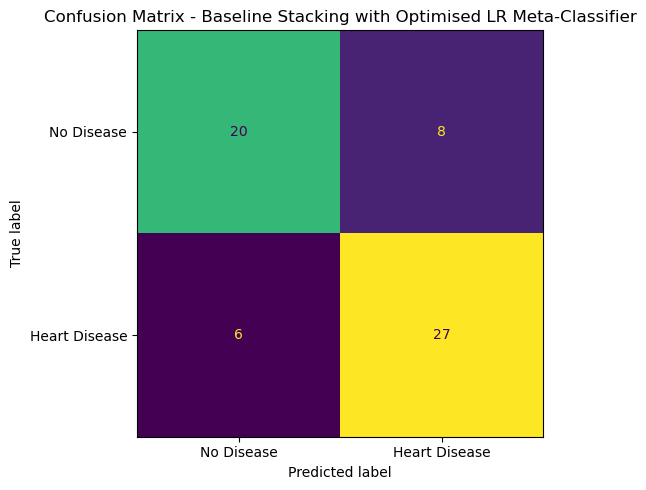

In [63]:
# Retrieve the best LR stacking model selected through training CV
best_baseline_stacking_p2 = (
    meta_stacking_searches_p2[
        "Logistic Regression Meta"
    ].best_estimator_
)

# Predictions on the untouched Part 2 test set
stacking_baseline_pred_p2 = best_baseline_stacking_p2.predict(
    X_test_p2
)

stacking_baseline_prob_p2 = (
    best_baseline_stacking_p2
    .predict_proba(X_test_p2)[:, 1]
)

# Confusion matrix
stacking_baseline_cm_p2 = confusion_matrix(
    y_test_p2,
    stacking_baseline_pred_p2
)

tn, fp, fn, tp = stacking_baseline_cm_p2.ravel()

# Evaluation metrics
stacking_baseline_accuracy_p2 = accuracy_score(
    y_test_p2,
    stacking_baseline_pred_p2
)

stacking_baseline_f1_p2 = f1_score(
    y_test_p2,
    stacking_baseline_pred_p2
)

stacking_baseline_recall_p2 = recall_score(
    y_test_p2,
    stacking_baseline_pred_p2
)

stacking_baseline_precision_p2 = precision_score(
    y_test_p2,
    stacking_baseline_pred_p2
)

stacking_baseline_sensitivity_p2 = stacking_baseline_recall_p2

stacking_baseline_specificity_p2 = (
    tn / (tn + fp)
)

stacking_baseline_mcc_p2 = matthews_corrcoef(
    y_test_p2,
    stacking_baseline_pred_p2
)

stacking_baseline_auc_p2 = roc_auc_score(
    y_test_p2,
    stacking_baseline_prob_p2
)


# Results table
baseline_stacking_selected_results_p2 = pd.DataFrame([{
    "Model": "Baseline Stacking - Optimised LR Meta",
    "Accuracy": stacking_baseline_accuracy_p2,
    "F1-Score": stacking_baseline_f1_p2,
    "Recall": stacking_baseline_recall_p2,
    "Precision": stacking_baseline_precision_p2,
    "Sensitivity": stacking_baseline_sensitivity_p2,
    "Specificity": stacking_baseline_specificity_p2,
    "MCC": stacking_baseline_mcc_p2,
    "AUC": stacking_baseline_auc_p2
}])

display(
    baseline_stacking_selected_results_p2.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)


# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=stacking_baseline_cm_p2,
    display_labels=[
        "No Disease",
        "Heart Disease"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax,
    colorbar=False,
    values_format="d"
)

ax.set_title(
    "Confusion Matrix - Baseline Stacking with Optimised LR Meta-Classifier"
)

plt.tight_layout()
plt.show()

### Baseline Stacking Evaluation Outcome

The selected Logistic Regression stacking architecture achieved an accuracy of 77.05%, F1-score of 0.7941 and AUC of 0.8853 on the 61 unseen clinical profiles. Its confusion matrix contained 20 true negatives and 27 true positives, with eight false positives and six false negatives, producing a sensitivity of 0.8182 and specificity of 0.7143.

The ensemble did not improve held-out accuracy beyond the strongest individual baseline classifiers, as Logistic Regression and Naive Bayes each achieved 78.69%. However, stacking produced the highest AUC observed at this stage, marginally exceeding Naive Bayes (0.8842) and improving upon Logistic Regression (0.8712) and KNN (0.8658). Interestingly, its binary classification metrics are identical to those obtained by KNN, while its AUC is 0.0195 higher, indicating that the stacking model provides better probability ranking despite producing the same classifications at the default decision threshold.

Therefore, baseline stacking does not yet provide a clear improvement in overall classification performance on unique clinical profiles. This establishes an important reference point before optimising the six underlying base classifiers, allowing the subsequent contribution of base-model tuning to be measured independently.

## Baseline Individual and Stacking Model Comparison

The selected baseline stacking ensemble is compared directly with the six individual classifiers under the same unique-profile evaluation protocol. This establishes the complete pre-optimisation benchmark for Part 2 and identifies whether stacking currently improves classification or probability discrimination before any base-classifier hyperparameters are modified.

In [65]:
baseline_individual_comparison_p2 = (
    baseline_results_p2_df
    .rename(columns={"F1": "F1-Score"})
    .copy()
)

# Combine six individual models with the selected stacking ensemble
baseline_all_models_p2 = pd.concat(
    [
        baseline_individual_comparison_p2,
        baseline_stacking_selected_results_p2
    ],
    ignore_index=True
)

# Rank models by AUC
baseline_all_models_p2 = (
    baseline_all_models_p2
    .sort_values(
        by="AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    baseline_all_models_p2.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Baseline Stacking - Optimised LR Meta,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8853
1,Naive Bayes,0.7869,0.7937,0.7576,0.8333,0.7576,0.8214,0.5771,0.8842
2,Logistic Regression,0.7869,0.8116,0.8485,0.7778,0.8485,0.7143,0.5702,0.8712
3,KNN,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8658
4,Random Forest,0.7377,0.7576,0.7576,0.7576,0.7576,0.7143,0.4719,0.8528
5,XGBoost,0.7213,0.7463,0.7576,0.7353,0.7576,0.6786,0.4376,0.8323
6,Decision Tree,0.7377,0.7500,0.7273,0.7742,0.7273,0.7500,0.4757,0.7386


### Pre-Optimisation Benchmark Outcome

The combined baseline comparison shows that the optimised Logistic Regression stacking architecture achieved the highest AUC among the seven evaluated models at 0.8853, narrowly exceeding Naive Bayes at 0.8842. However, this improvement in probability discrimination did not translate into superior threshold-based classification. Logistic Regression and Naive Bayes each achieved the highest accuracy of 78.69%, while Logistic Regression also produced the highest F1-score of 0.8116. The stacking ensemble achieved 77.05% accuracy and an F1-score of 0.7941.

The tree-based classifiers remained substantially weaker under the unique-profile evaluation protocol, with Random Forest, Decision Tree and XGBoost achieving accuracies between 72.13% and 73.77%. These results establish the complete pre-optimisation benchmark for Part 2. Although stacking provides the strongest AUC, its advantage is marginal and its classification performance remains below the strongest individual baseline models. The next stage therefore investigates whether systematic optimisation of the six base classifiers can improve their generalisation before reconstructing the final stacking ensemble.

## Hyperparameter Optimisation of the Base Classifiers

The six individual classifiers are now optimised using only the 241-profile training subset. Five-fold stratified cross-validation is used to evaluate candidate parameter configurations while preserving the target distribution across validation folds. Preprocessing is incorporated within each classifier pipeline so that scaling parameters are learned independently within each training fold. ROC-AUC is adopted as the primary optimisation criterion, with Accuracy and F1-score retained as complementary validation measures. The 61-profile held-out test subset remains excluded from all hyperparameter selection.

In [66]:
from sklearn.model_selection import GridSearchCV

base_tuning_cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Logistic Regression

lr_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ))
])

lr_param_grid_p2 = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"]
}


# Decision Trees

dt_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ))
])

dt_param_grid_p2 = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [2, 3, 4, 5, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}


# Random Forest

rf_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_grid_p2 = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 5, 10, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}


# XGBoost

xgb_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_param_grid_p2 = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [2, 3, 5],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}


# Naive Bayes

nb_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", GaussianNB())
])

nb_param_grid_p2 = {
    "model__var_smoothing": [
        1e-12,
        1e-10,
        1e-9,
        1e-8,
        1e-7,
        1e-6
    ]
}


# KNN

knn_tuning_pipeline_p2 = Pipeline([
    ("preprocess", clone(preprocessor_p2)),
    ("model", KNeighborsClassifier())
])

knn_param_grid_p2 = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

### Cross-Validated Base-Classifier Optimisation

Each classifier is now tuned independently using five-fold stratified cross-validation on the 241-profile training subset. For every candidate configuration, ROC-AUC is used as the primary selection criterion, while Accuracy and F1-score are recorded as supporting measures. The best-performing configuration for each classifier is retained for later held-out evaluation and final stacking. Because all searches are performed entirely within the training data, the 61-profile test subset remains untouched during model selection.

In [69]:
base_searches_p2 = {
    "Logistic Regression": GridSearchCV(
        estimator=lr_tuning_pipeline_p2,
        param_grid=lr_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "Decision Tree": GridSearchCV(
        estimator=dt_tuning_pipeline_p2,
        param_grid=dt_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "Random Forest": GridSearchCV(
        estimator=rf_tuning_pipeline_p2,
        param_grid=rf_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "XGBoost": GridSearchCV(
        estimator=xgb_tuning_pipeline_p2,
        param_grid=xgb_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "Naive Bayes": GridSearchCV(
        estimator=nb_tuning_pipeline_p2,
        param_grid=nb_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    ),

    "KNN": GridSearchCV(
        estimator=knn_tuning_pipeline_p2,
        param_grid=knn_param_grid_p2,
        scoring={
            "AUC": "roc_auc",
            "Accuracy": "accuracy",
            "F1": "f1"
        },
        refit="AUC",
        cv=base_tuning_cv_p2,
        n_jobs=-1,
        return_train_score=True
    )
}


base_tuning_summary_p2 = []

for name, search in base_searches_p2.items():

    print(f"Tuning {name}")

    search.fit(
        X_train_p2,
        y_train_p2
    )

    best_index = search.best_index_

    base_tuning_summary_p2.append({
        "Model": name,

        "CV AUC":
            search.cv_results_[
                "mean_test_AUC"
            ][best_index],

        "CV AUC Std":
            search.cv_results_[
                "std_test_AUC"
            ][best_index],

        "CV Accuracy":
            search.cv_results_[
                "mean_test_Accuracy"
            ][best_index],

        "CV F1-Score":
            search.cv_results_[
                "mean_test_F1"
            ][best_index],

        "Best Parameters":
            search.best_params_
    })

    print(
        f"Best CV AUC: "
        f"{search.best_score_:.4f}"
    )

    print(
        f"Best parameters: "
        f"{search.best_params_}"
    )

    print()

Tuning Logistic Regression
Best CV AUC: 0.9143
Best parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Tuning Decision Tree
Best CV AUC: 0.8747
Best parameters: {'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}

Tuning Random Forest
Best CV AUC: 0.9152
Best parameters: {'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}

Tuning XGBoost
Best CV AUC: 0.9139
Best parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}

Tuning Naive Bayes
Best CV AUC: 0.8950
Best parameters: {'model__var_smoothing': 1e-12}

Tuning KNN
Best CV AUC: 0.9197
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}



### Base-Classifier Optimisation Summary

The optimised classifiers are compared using their mean cross-validation AUC, Accuracy and F1-score, together with AUC standard deviation across folds. This comparison identifies which individual learners benefit most from systematic parameter selection and provides the tuned base-model configurations that will subsequently be evaluated on the held-out test subset and incorporated into the final stacking architecture.

In [70]:
base_tuning_summary_p2_df = (
    pd.DataFrame(base_tuning_summary_p2)
    .sort_values(
        by="CV AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    base_tuning_summary_p2_df.style.format({
        "CV AUC": "{:.4f}",
        "CV AUC Std": "{:.4f}",
        "CV Accuracy": "{:.4f}",
        "CV F1-Score": "{:.4f}"
    })
)

,Model,CV AUC,CV AUC Std,CV Accuracy,CV F1-Score,Best Parameters
0,KNN,0.9197,0.0385,0.8547,0.8717,"{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance'}"
1,Random Forest,0.9152,0.0503,0.8502,0.8712,"{'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}"
2,Logistic Regression,0.9143,0.0353,0.8503,0.8699,"{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'liblinear'}"
3,XGBoost,0.9139,0.0516,0.8255,0.8485,"{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}"
4,Naive Bayes,0.8950,0.0469,0.8172,0.8378,{'model__var_smoothing': 1e-12}
5,Decision Tree,0.8747,0.0312,0.7843,0.7955,"{'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10}"


### Base-Classifier Optimisation Outcome

Hyperparameter optimisation produced strong and relatively consistent cross-validated discrimination across several classifiers. KNN achieved the highest mean validation AUC of 0.9197, followed by Random Forest at 0.9152, Logistic Regression at 0.9143 and XGBoost at 0.9139. KNN also produced the highest validation Accuracy (0.8547) and F1-score (0.8717), using 15 neighbours, Manhattan distance and distance-weighted voting.

The optimisation results also indicate that controlling model complexity is important on the refined dataset. Random Forest selected a maximum depth of only 3 with 300 estimators, while XGBoost selected a depth of 3 and a comparatively low learning rate of 0.01. Decision Tree similarly favoured a restricted depth of 4 with larger minimum split and leaf requirements. These configurations contrast with the substantially more flexible baseline tree models and suggest that regularisation may improve generalisation across distinct clinical profiles.

Logistic Regression remained highly competitive with a mean AUC of 0.9143 using L2 regularisation and `C = 10`, while Naive Bayes and Decision Tree achieved lower mean AUC values of 0.8950 and 0.8747 respectively. These results identify the strongest training-level configurations without consulting the held-out test subset. The selected estimators are therefore carried forward for independent evaluation on the 61 unseen clinical profiles.

## Held-Out Evaluation of the Optimised Base Classifiers

The best configuration identified for each classifier through training-only cross-validation is now evaluated once on the isolated 61-profile test subset. The same Accuracy, F1-score, Recall, Precision, Sensitivity, Specificity, MCC and AUC measures are retained to ensure direct comparison with the corresponding untuned Part 2 baselines. Predictions and probability estimates are stored for subsequent confusion-matrix, ROC and optimisation-effect analyses.

In [73]:
tuned_results_p2 = []
tuned_predictions_p2 = {}
tuned_probabilities_p2 = {}


for name, search in base_searches_p2.items():

    # Best model already refitted on all 241 training profiles
    best_model = search.best_estimator_

    # Predictions on the untouched test set
    y_pred = best_model.predict(X_test_p2)

    # Positive-class probabilities
    y_prob = best_model.predict_proba(X_test_p2)[:, 1]

    tuned_predictions_p2[name] = y_pred
    tuned_probabilities_p2[name] = y_prob

    # Confusion-matrix components
    tn, fp, fn, tp = confusion_matrix(
        y_test_p2,
        y_pred
    ).ravel()

    # Evaluation metrics
    accuracy = accuracy_score(
        y_test_p2,
        y_pred
    )

    f1 = f1_score(
        y_test_p2,
        y_pred
    )

    recall = recall_score(
        y_test_p2,
        y_pred
    )

    precision = precision_score(
        y_test_p2,
        y_pred
    )

    sensitivity = recall

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0
    )

    mcc = matthews_corrcoef(
        y_test_p2,
        y_pred
    )

    auc = roc_auc_score(
        y_test_p2,
        y_prob
    )

    tuned_results_p2.append({
        "Model": name,
        "Accuracy": accuracy,
        "F1-Score": f1,
        "Recall": recall,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "MCC": mcc,
        "AUC": auc
    })


tuned_results_p2_df = pd.DataFrame(
    tuned_results_p2
)


display(
    tuned_results_p2_df.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Logistic Regression,0.7869,0.8116,0.8485,0.7778,0.8485,0.7143,0.5702,0.8690
1,Decision Tree,0.7213,0.7385,0.7273,0.7500,0.7273,0.7143,0.4406,0.8328
2,Random Forest,0.8197,0.8406,0.8788,0.8056,0.8788,0.7500,0.6371,0.8755
3,XGBoost,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8626
4,Naive Bayes,0.7869,0.7937,0.7576,0.8333,0.7576,0.8214,0.5771,0.8842
5,KNN,0.8033,0.8286,0.8788,0.7838,0.8788,0.7143,0.6050,0.8772


### Optimised Base-Classifier Evaluation Outcome

Hyperparameter optimisation produced the largest improvement for Random Forest. Its held-out accuracy increased from 73.77% to 81.97%, an improvement of 8.20 percentage points, while F1-score increased from 0.7576 to 0.8406 and recall from 0.7576 to 0.8788. Its MCC also increased substantially from 0.4719 to 0.6371, indicating improved overall class-level prediction quality. XGBoost similarly improved from 72.13% to 77.05% accuracy, with its AUC increasing from 0.8323 to 0.8626. KNN improved from 77.05% to 80.33% accuracy and achieved an F1-score of 0.8286.

Logistic Regression and Naive Bayes showed little change after optimisation. Logistic Regression retained an accuracy of 78.69%, while its AUC decreased slightly from 0.8712 to 0.8690. Naive Bayes produced effectively unchanged classification performance and retained the highest individual-model AUC of 0.8842. Decision Tree showed a mixed response: its accuracy decreased from 73.77% to 72.13%, although its AUC increased substantially from 0.7386 to 0.8328, indicating improved probability ranking despite weaker threshold-based classification.

Overall, Random Forest becomes the strongest optimised classifier in terms of Accuracy (81.97%), F1-score (0.8406), Recall (0.8788) and MCC (0.6371), whereas Naive Bayes remains strongest in AUC (0.8842), Precision (0.8333) and Specificity (0.8214). These complementary strengths provide a stronger foundation for reconstructing the final stacking ensemble.

## Effect of Base-Classifier Hyperparameter Optimisation

The optimised classifiers are compared directly with their corresponding untuned Part 2 baselines to quantify the contribution of systematic parameter selection. Because both experiments use the same 241-profile training set, 61-profile test set and preprocessing specification, the observed differences primarily reflect changes in classifier configuration rather than dataset composition or evaluation protocol.

In [74]:
# Standardise F1 naming in the untuned baseline table
untuned_comparison_p2 = (
    baseline_results_p2_df
    .rename(columns={"F1": "F1-Score"})
    .copy()
)

tuned_comparison_p2 = tuned_results_p2_df.copy()

comparison_metrics_p2 = [
    "Accuracy",
    "F1-Score",
    "Recall",
    "Precision",
    "Specificity",
    "MCC",
    "AUC"
]

tuning_effect_p2 = (
    untuned_comparison_p2[
        ["Model"] + comparison_metrics_p2
    ]
    .merge(
        tuned_comparison_p2[
            ["Model"] + comparison_metrics_p2
        ],
        on="Model",
        suffixes=("_Untuned", "_Tuned")
    )
)

for metric in comparison_metrics_p2:
    tuning_effect_p2[
        f"{metric}_Difference"
    ] = (
        tuning_effect_p2[f"{metric}_Tuned"]
        - tuning_effect_p2[f"{metric}_Untuned"]
    )

ordered_columns = ["Model"]

for metric in comparison_metrics_p2:
    ordered_columns.extend([
        f"{metric}_Untuned",
        f"{metric}_Tuned",
        f"{metric}_Difference"
    ])

tuning_effect_p2 = tuning_effect_p2[
    ordered_columns
]

format_dict = {}

for column in tuning_effect_p2.columns:
    if column == "Model":
        continue

    if "Difference" in column:
        format_dict[column] = "{:+.4f}"
    else:
        format_dict[column] = "{:.4f}"

display(
    tuning_effect_p2.style.format(
        format_dict
    )
)

,Model,Accuracy_Untuned,Accuracy_Tuned,Accuracy_Difference,F1-Score_Untuned,F1-Score_Tuned,F1-Score_Difference,Recall_Untuned,Recall_Tuned,Recall_Difference,Precision_Untuned,Precision_Tuned,Precision_Difference,Specificity_Untuned,Specificity_Tuned,Specificity_Difference,MCC_Untuned,MCC_Tuned,MCC_Difference,AUC_Untuned,AUC_Tuned,AUC_Difference
0,Logistic Regression,0.7869,0.7869,+0.0000,0.8116,0.8116,+0.0000,0.8485,0.8485,+0.0000,0.7778,0.7778,+0.0000,0.7143,0.7143,+0.0000,0.5702,0.5702,+0.0000,0.8712,0.8690,-0.0022
1,Decision Tree,0.7377,0.7213,-0.0164,0.7500,0.7385,-0.0115,0.7273,0.7273,+0.0000,0.7742,0.7500,-0.0242,0.7500,0.7143,-0.0357,0.4757,0.4406,-0.0351,0.7386,0.8328,+0.0942
2,Random Forest,0.7377,0.8197,+0.0820,0.7576,0.8406,+0.0830,0.7576,0.8788,+0.1212,0.7576,0.8056,+0.0480,0.7143,0.7500,+0.0357,0.4719,0.6371,+0.1653,0.8528,0.8755,+0.0227
3,XGBoost,0.7213,0.7705,+0.0492,0.7463,0.7941,+0.0478,0.7576,0.8182,+0.0606,0.7353,0.7714,+0.0361,0.6786,0.7143,+0.0357,0.4376,0.5365,+0.0990,0.8323,0.8626,+0.0303
4,Naive Bayes,0.7869,0.7869,+0.0000,0.7937,0.7937,+0.0000,0.7576,0.7576,+0.0000,0.8333,0.8333,+0.0000,0.8214,0.8214,+0.0000,0.5771,0.5771,+0.0000,0.8842,0.8842,+0.0000
5,KNN,0.7705,0.8033,+0.0328,0.7941,0.8286,+0.0345,0.8182,0.8788,+0.0606,0.7714,0.7838,+0.0124,0.7143,0.7143,+0.0000,0.5365,0.6050,+0.0684,0.8658,0.8772,+0.0114


## Final Stacking Architecture with Optimised Base Classifiers

The six optimised base classifiers are now incorporated into the stacking architecture, while Logistic Regression is retained as the meta-classifier because it achieved the strongest cross-validated AUC during the earlier meta-classifier comparison. Since optimisation of the base learners changes the probability information supplied to the meta-level model, the Logistic Regression regularisation parameters are re-optimised using training-only cross-validation. The held-out 61-profile test subset remains excluded from this final model-selection stage.

In [76]:
# Tuned base classifiers for the final stacking architecture

tuned_stacking_estimators_p2 = [
    (
        "lr",
        clone(
            base_searches_p2[
                "Logistic Regression"
            ].best_estimator_
        )
    ),

    (
        "dt",
        clone(
            base_searches_p2[
                "Decision Tree"
            ].best_estimator_
        )
    ),

    (
        "rf",
        clone(
            base_searches_p2[
                "Random Forest"
            ].best_estimator_
        )
    ),

    (
        "xgb",
        clone(
            base_searches_p2[
                "XGBoost"
            ].best_estimator_
        )
    ),

    (
        "nb",
        clone(
            base_searches_p2[
                "Naive Bayes"
            ].best_estimator_
        )
    ),

    (
        "knn",
        clone(
            base_searches_p2[
                "KNN"
            ].best_estimator_
        )
    )
]


# 5-fold OOF generation inside the stacking model
final_stacking_inner_cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)


# Complete tuned stacking architecture
final_stacking_lr_p2 = StackingClassifier(
    estimators=tuned_stacking_estimators_p2,

    final_estimator=LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    cv=final_stacking_inner_cv_p2,
    stack_method="predict_proba",
    passthrough=False,
    n_jobs=1
)


# Re-optimise only the LR meta-classifier
final_lr_meta_grid_p2 = {
    "final_estimator__C": [
        0.01,
        0.1,
        1,
        10,
        100
    ],

    "final_estimator__penalty": [
        "l1",
        "l2"
    ],

    "final_estimator__solver": [
        "liblinear"
    ]
}


# Training-only CV for final meta-level optimisation
final_meta_cv_p2 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE + 1
)


final_stacking_search_p2 = GridSearchCV(
    estimator=final_stacking_lr_p2,

    param_grid=final_lr_meta_grid_p2,

    scoring={
        "AUC": "roc_auc",
        "Accuracy": "accuracy",
        "F1": "f1"
    },

    refit="AUC",

    cv=final_meta_cv_p2,

    n_jobs=-1,

    return_train_score=True
)


print("Optimising final tuned stacking ensemble...")

final_stacking_search_p2.fit(
    X_train_p2,
    y_train_p2
)


best_index = final_stacking_search_p2.best_index_

print(
    f"Best CV AUC: "
    f"{final_stacking_search_p2.best_score_:.4f}"
)

print(
    f"Best CV Accuracy: "
    f"{final_stacking_search_p2.cv_results_['mean_test_Accuracy'][best_index]:.4f}"
)

print(
    f"Best CV F1-Score: "
    f"{final_stacking_search_p2.cv_results_['mean_test_F1'][best_index]:.4f}"
)

print(
    f"Best LR meta-classifier parameters:\n"
    f"{final_stacking_search_p2.best_params_}"
)

Optimising final tuned stacking ensemble...
Best CV AUC: 0.9193
Best CV Accuracy: 0.7718
Best CV F1-Score: 0.8284
Best LR meta-classifier parameters:
{'final_estimator__C': 0.01, 'final_estimator__penalty': 'l2', 'final_estimator__solver': 'liblinear'}


### Final Meta-Classifier Optimisation Outcome

Re-optimising the Logistic Regression meta-classifier after introducing the six tuned base learners produced a mean cross-validation AUC of 0.9193, with an Accuracy of 0.7718 and F1-score of 0.8284. The optimal meta-classifier retained L2 regularisation and the `liblinear` solver but selected a substantially lower regularisation parameter of `C = 0.01`. This indicates that stronger regularisation was preferred once the probability outputs of the optimised base classifiers were combined.

The final training-level AUC of 0.9193 is slightly higher than the 0.9126 obtained when Logistic Regression was optimised over the original untuned base classifiers. This provides evidence that the revised stacking architecture improves cross-validated probability discrimination. However, no conclusion regarding final generalisation is made at this stage because the 61-profile held-out test subset has not yet been used for evaluating the optimised ensemble.

## Final Held-Out Evaluation of the Optimised Stacking Ensemble

The fully optimised stacking architecture is now evaluated on the 61-profile held-out test subset. The final ensemble combines the six independently tuned base classifiers with the re-optimised Logistic Regression meta-classifier selected exclusively through training-level cross-validation. Accuracy, F1-score, Recall, Precision, Sensitivity, Specificity, MCC and AUC are calculated using the same evaluation framework applied throughout the study. This constitutes the first and only held-out evaluation of the final optimised stacking configuration.

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Final Optimised Stacking,0.8033,0.8421,0.9697,0.7442,0.9697,0.6071,0.6303,0.8896


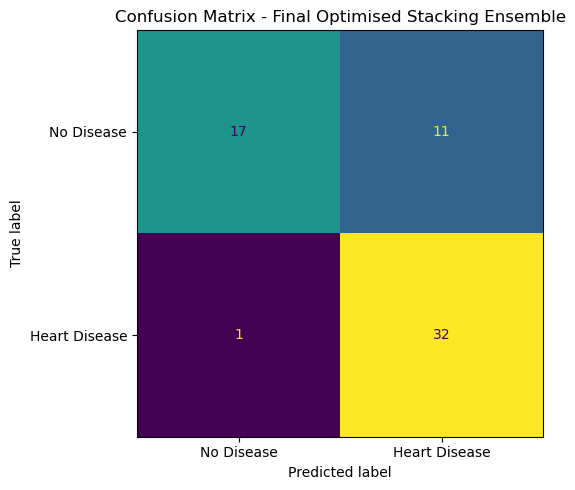

In [79]:
# Retrieve the final stacking model selected through training-only CV
final_optimised_stacking_p2 = (
    final_stacking_search_p2.best_estimator_
)

# Predictions on the held-out test set

final_stacking_pred_p2 = (
    final_optimised_stacking_p2.predict(
        X_test_p2
    )
)

final_stacking_prob_p2 = (
    final_optimised_stacking_p2
    .predict_proba(X_test_p2)[:, 1]
)

# Confusion matrix

final_stacking_cm_p2 = confusion_matrix(
    y_test_p2,
    final_stacking_pred_p2
)

tn, fp, fn, tp = final_stacking_cm_p2.ravel()


# Evaluation metrics

final_stacking_accuracy_p2 = accuracy_score(
    y_test_p2,
    final_stacking_pred_p2
)

final_stacking_f1_p2 = f1_score(
    y_test_p2,
    final_stacking_pred_p2
)

final_stacking_recall_p2 = recall_score(
    y_test_p2,
    final_stacking_pred_p2
)

final_stacking_precision_p2 = precision_score(
    y_test_p2,
    final_stacking_pred_p2
)

final_stacking_sensitivity_p2 = (
    final_stacking_recall_p2
)

final_stacking_specificity_p2 = (
    tn / (tn + fp)
)

final_stacking_mcc_p2 = matthews_corrcoef(
    y_test_p2,
    final_stacking_pred_p2
)

final_stacking_auc_p2 = roc_auc_score(
    y_test_p2,
    final_stacking_prob_p2
)


# Final results table
final_stacking_results_p2 = pd.DataFrame([{
    "Model": "Final Optimised Stacking",
    "Accuracy": final_stacking_accuracy_p2,
    "F1-Score": final_stacking_f1_p2,
    "Recall": final_stacking_recall_p2,
    "Precision": final_stacking_precision_p2,
    "Sensitivity": final_stacking_sensitivity_p2,
    "Specificity": final_stacking_specificity_p2,
    "MCC": final_stacking_mcc_p2,
    "AUC": final_stacking_auc_p2
}])


display(
    final_stacking_results_p2.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)


# Plot confusion matrix

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_stacking_cm_p2,
    display_labels=[
        "No Disease",
        "Heart Disease"
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp.plot(
    ax=ax,
    colorbar=False,
    values_format="d"
)

ax.set_title(
    "Confusion Matrix - Final Optimised Stacking Ensemble"
)

plt.tight_layout()
plt.show()

### Final Optimised Stacking Evaluation Outcome

The final optimised stacking ensemble achieved an accuracy of 80.33%, F1-score of 0.8421 and AUC of 0.8896 on the 61 held-out clinical profiles. The model correctly identified 32 of the 33 heart-disease cases, producing a sensitivity of 0.9697 and only one false negative. However, this high sensitivity was accompanied by 11 false positives, reducing specificity to 0.6071 and precision to 0.7442.

Compared with the earlier baseline stacking model, the optimised ensemble improved accuracy from 77.05% to 80.33%, F1-score from 0.7941 to 0.8421, MCC from 0.5365 to 0.6303 and AUC from 0.8853 to 0.8896. The largest change occurred in sensitivity, which increased from 0.8182 to 0.9697.

The tuned Random Forest remained slightly stronger in overall accuracy (81.97%) and MCC (0.6371), but the final stacking ensemble achieved a higher F1-score, substantially higher sensitivity and a higher AUC. The ensemble therefore provides the strongest positive-case detection among the optimised models, although this improvement is achieved at the cost of lower specificity. This trade-off is particularly important when interpreting the final model rather than relying on accuracy alone.

## ROC Curve Comparison of Optimised Models

Receiver Operating Characteristic (ROC) curves are compared across the six optimised individual classifiers, the earlier baseline stacking ensemble and the final optimised stacking architecture. All curves are calculated using predicted probabilities on the same 61-profile held-out test subset, allowing discrimination performance to be compared independently of a single classification threshold. The Area Under the ROC Curve (AUC) is included in the legend for each model, while the diagonal reference line represents no-discrimination performance.

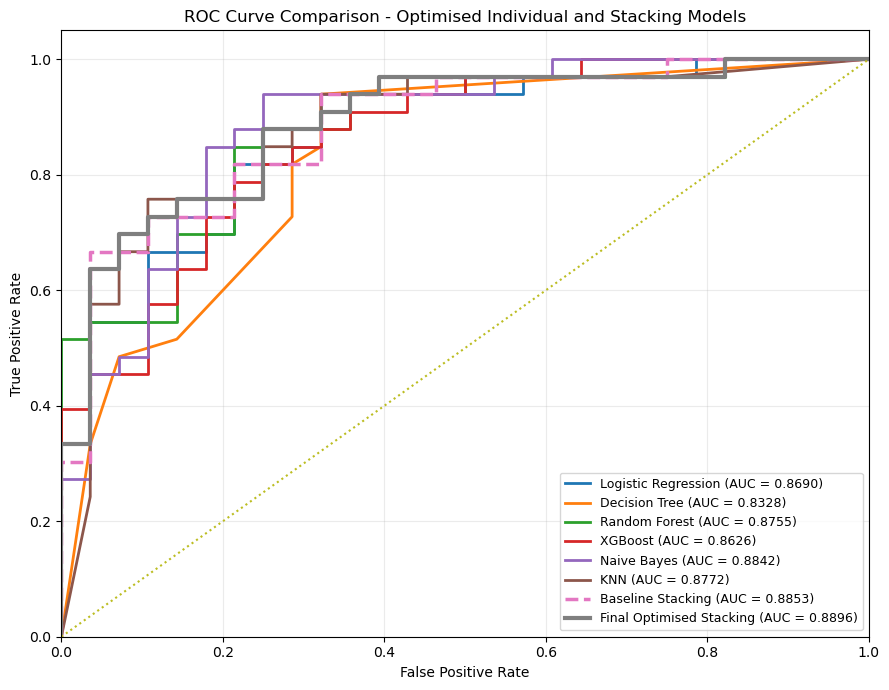

In [81]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(9, 7))

# Tuned individual classifiers

for name, y_prob in tuned_probabilities_p2.items():

    fpr, tpr, _ = roc_curve(
        y_test_p2,
        y_prob
    )

    auc_value = roc_auc_score(
        y_test_p2,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_value:.4f})"
    )


# Baseline stacking ensemble
baseline_stack_fpr, baseline_stack_tpr, _ = roc_curve(
    y_test_p2,
    stacking_baseline_prob_p2
)

baseline_stack_auc = roc_auc_score(
    y_test_p2,
    stacking_baseline_prob_p2
)

plt.plot(
    baseline_stack_fpr,
    baseline_stack_tpr,
    linewidth=2.5,
    linestyle="--",
    label=f"Baseline Stacking (AUC = {baseline_stack_auc:.4f})"
)

# Final optimised stacking ensemble

final_stack_fpr, final_stack_tpr, _ = roc_curve(
    y_test_p2,
    final_stacking_prob_p2
)

final_stack_auc = roc_auc_score(
    y_test_p2,
    final_stacking_prob_p2
)

plt.plot(
    final_stack_fpr,
    final_stack_tpr,
    linewidth=3,
    label=f"Final Optimised Stacking (AUC = {final_stack_auc:.4f})"
)


# No-skill reference

plt.plot(
    [0, 1],
    [0, 1],
    linestyle=":",
    linewidth=1.5,
)


# Figure formatting

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison - Optimised Individual and Stacking Models"
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.grid(
    alpha=0.25
)

plt.legend(
    loc="lower right",
    fontsize=9
)

plt.tight_layout()
plt.show()

### ROC Curve Comparison Outcome

The ROC comparison shows that the final optimised stacking ensemble achieved the highest held-out AUC of 0.8896, followed closely by the baseline stacking model (0.8853) and Naive Bayes (0.8842). KNN and Random Forest also demonstrated strong discrimination with AUC values of 0.8772 and 0.8755 respectively, while Decision Tree produced the lowest AUC at 0.8328. Relative to the baseline stacking architecture, optimisation increased AUC by 0.0043, indicating a modest improvement in probability-ranking performance after tuning the base classifiers and re-optimising the Logistic Regression meta-classifier. Although the final ensemble ranks cases most effectively overall, the small differences between the leading models should be interpreted cautiously given the 61-profile test set. The ROC evidence therefore supports the final stacking model while also demonstrating that several optimised individual classifiers remain competitive.

## Overall Stacking Model Comparison

The final comparison focuses exclusively on the progression of the stacking methodology. The published ensemble reported by the original study [1] is compared with the Part 1 reproduction, the Part 2 baseline stacking model evaluated on unique clinical profiles, and the final optimised Part 2 stacking architecture. This separates the effect of the refined evaluation protocol from the subsequent contribution of base-classifier and meta-classifier optimisation.

In [84]:
### Published stacking result reported in the paper

published_stacking_row = {
    "Model": "Published Stacking [1]",
    "Accuracy": 0.9853,
    "F1-Score": 0.9861,
    "Recall": 0.9727,
    "Precision": 1.0000,
    "Sensitivity": 0.9853,
    "Specificity": 0.9861,
    "MCC": 1.0000,
    "AUC": 0.9880
}


# Part 1 reproduced stacking result

part1_stacking_row = {
    "Model": "Part 1 Reproduced Stacking",
    "Accuracy": 0.9854,
    "F1-Score": 0.9852,
    "Recall": 0.9709,
    "Precision": 1.0000,
    "Sensitivity": 0.9709,
    "Specificity": 1.0000,
    "MCC": 0.9712,
    "AUC": 1.0000
}


# Part 2 baseline stacking result

part2_baseline_stack_row = (
    baseline_stacking_selected_results_p2
    .iloc[0]
    .to_dict()
)

part2_baseline_stack_row["Model"] = (
    "Part 2 Baseline Stacking"
)


# Part 2 final optimised stacking result

part2_final_stack_row = (
    final_stacking_results_p2
    .iloc[0]
    .to_dict()
)

part2_final_stack_row["Model"] = (
    "Part 2 Final Optimised Stacking"
)


# Final comparison table

overall_stacking_comparison_p2 = pd.DataFrame([
    published_stacking_row,
    part1_stacking_row,
    part2_baseline_stack_row,
    part2_final_stack_row
])


overall_stacking_comparison_p2 = overall_stacking_comparison_p2[
    [
        "Model",
        "Accuracy",
        "F1-Score",
        "Recall",
        "Precision",
        "Sensitivity",
        "Specificity",
        "MCC",
        "AUC"
    ]
]


display(
    overall_stacking_comparison_p2.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)

,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Published Stacking [1],0.9853,0.9861,0.9727,1.0000,0.9853,0.9861,1.0000,0.9880
1,Part 1 Reproduced Stacking,0.9854,0.9852,0.9709,1.0000,0.9709,1.0000,0.9712,1.0000
2,Part 2 Baseline Stacking,0.7705,0.7941,0.8182,0.7714,0.8182,0.7143,0.5365,0.8853
3,Part 2 Final Optimised Stacking,0.8033,0.8421,0.9697,0.7442,0.9697,0.6071,0.6303,0.8896


### Overall Stacking Comparison Outcome

The final comparison demonstrates a substantial distinction between the original evaluation setting and the refined Part 2 protocol. The Part 1 reproduction achieved 98.54% accuracy and an AUC of 1.0000, closely reproducing the published stacking accuracy of 98.53%. In contrast, restricting evaluation to distinct clinical profiles reduced the Part 2 baseline stacking model to 77.05% accuracy and an AUC of 0.8853, indicating that the near-perfect performance observed in Part 1 did not persist under the more restrictive evaluation setting.

Optimisation subsequently improved the refined stacking architecture. Accuracy increased from 77.05% to 80.33%, F1-score from 0.7941 to 0.8421, and MCC from 0.5365 to 0.6303. AUC also increased from 0.8853 to 0.8896. The largest improvement occurred in sensitivity, which increased from 0.8182 to 0.9697, meaning that 32 of the 33 heart-disease cases in the held-out test set were correctly identified.

This increase in disease detection was accompanied by a reduction in specificity from 0.7143 to 0.6071 and precision from 0.7714 to 0.7442. The final ensemble therefore favours sensitivity over false-positive control, demonstrating that optimisation improved positive-case detection rather than uniformly improving every metric.

## Bootstrap Confidence-Interval Analysis

Because the final held-out evaluation contains only 61 distinct clinical profiles, point estimates alone may not fully represent the uncertainty associated with model performance. A stratified bootstrap procedure is therefore applied to the final optimised stacking predictions to estimate 95% confidence intervals for the principal evaluation metrics. Positive and negative cases are resampled separately with replacement so that the original class composition is preserved within each bootstrap sample. This analysis does not retrain or re-optimise the model and therefore leaves the experimental pipeline unchanged.

In [87]:
# Stratified bootstrap confidence intervals
# Final optimised stacking model

BOOTSTRAP_ITERATIONS = 5000
BOOTSTRAP_SEED = RANDOM_STATE

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

# Convert to NumPy arrays for indexing
y_true_boot = np.asarray(y_test_p2)
y_pred_boot = np.asarray(final_stacking_pred_p2)
y_prob_boot = np.asarray(final_stacking_prob_p2)

# Separate indices by true class
negative_indices = np.where(
    y_true_boot == 0
)[0]

positive_indices = np.where(
    y_true_boot == 1
)[0]


bootstrap_metrics_p2 = {
    "Accuracy": [],
    "F1-Score": [],
    "Recall": [],
    "Precision": [],
    "Sensitivity": [],
    "Specificity": [],
    "MCC": [],
    "AUC": []
}


for _ in range(BOOTSTRAP_ITERATIONS):

    # Resample each class independently with replacement
    sampled_negative = rng.choice(
        negative_indices,
        size=len(negative_indices),
        replace=True
    )

    sampled_positive = rng.choice(
        positive_indices,
        size=len(positive_indices),
        replace=True
    )

    sampled_indices = np.concatenate([
        sampled_negative,
        sampled_positive
    ])

    y_true_sample = y_true_boot[
        sampled_indices
    ]

    y_pred_sample = y_pred_boot[
        sampled_indices
    ]

    y_prob_sample = y_prob_boot[
        sampled_indices
    ]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_true_sample,
        y_pred_sample,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    # Store metrics
    bootstrap_metrics_p2[
        "Accuracy"
    ].append(
        accuracy_score(
            y_true_sample,
            y_pred_sample
        )
    )

    bootstrap_metrics_p2[
        "F1-Score"
    ].append(
        f1_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        )
    )

    bootstrap_metrics_p2[
        "Recall"
    ].append(
        recall_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        )
    )

    bootstrap_metrics_p2[
        "Precision"
    ].append(
        precision_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        )
    )

    bootstrap_metrics_p2[
        "Sensitivity"
    ].append(
        recall_score(
            y_true_sample,
            y_pred_sample,
            zero_division=0
        )
    )

    bootstrap_metrics_p2[
        "Specificity"
    ].append(
        specificity
    )

    bootstrap_metrics_p2[
        "MCC"
    ].append(
        matthews_corrcoef(
            y_true_sample,
            y_pred_sample
        )
    )

    bootstrap_metrics_p2[
        "AUC"
    ].append(
        roc_auc_score(
            y_true_sample,
            y_prob_sample
        )
    )
    
# Calculate 95% percentile confidence intervals

point_estimates_p2 = {
    "Accuracy": final_stacking_accuracy_p2,
    "F1-Score": final_stacking_f1_p2,
    "Recall": final_stacking_recall_p2,
    "Precision": final_stacking_precision_p2,
    "Sensitivity": final_stacking_sensitivity_p2,
    "Specificity": final_stacking_specificity_p2,
    "MCC": final_stacking_mcc_p2,
    "AUC": final_stacking_auc_p2
}


bootstrap_ci_rows_p2 = []

for metric, values in bootstrap_metrics_p2.items():

    values = np.asarray(values)

    lower = np.percentile(
        values,
        2.5
    )

    upper = np.percentile(
        values,
        97.5
    )

    bootstrap_ci_rows_p2.append({
        "Metric": metric,
        "Point Estimate": point_estimates_p2[metric],
        "95% CI Lower": lower,
        "95% CI Upper": upper
    })


bootstrap_ci_p2_df = pd.DataFrame(
    bootstrap_ci_rows_p2
)


display(
    bootstrap_ci_p2_df.style.format({
        "Point Estimate": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Accuracy,0.8033,0.7049,0.8852
1,F1-Score,0.8421,0.7792,0.9041
2,Recall,0.9697,0.9091,1.0000
3,Precision,0.7442,0.6600,0.8421
4,Sensitivity,0.9697,0.9091,1.0000
5,Specificity,0.6071,0.4286,0.7857
6,MCC,0.6303,0.4545,0.7866
7,AUC,0.8896,0.8030,0.9610


### Bootstrap Confidence-Interval Outcome

The bootstrap analysis indicates that the final optimised stacking ensemble maintains strong disease-detection performance despite uncertainty arising from the relatively small held-out sample. Sensitivity was estimated at 0.9697 with a 95% confidence interval of 0.9091–1.0000, suggesting that the model's high recall for heart-disease cases is comparatively stable under repeated resampling. The AUC estimate of 0.8896 was also supported by an interval of 0.8030–0.9610, indicating consistently useful discriminatory ability across the bootstrap samples.

Greater uncertainty was observed for specificity, which had a point estimate of 0.6071 and a considerably wider interval of 0.4286–0.7857. Precision similarly ranged from 0.6600 to 0.8421, reflecting uncertainty in the model's false-positive behaviour. Accuracy ranged from 0.7049 to 0.8852, while MCC ranged from 0.4545 to 0.7866.

Overall, the uncertainty analysis supports the conclusion that the final ensemble is particularly strong at identifying positive heart-disease cases, while its ability to correctly exclude non-disease cases is less stable. The width of several intervals also reinforces the need to interpret the held-out results cautiously given the 61-profile test subset.

The bootstrap intervals quantify uncertainty conditional on the fitted model and held-out test sample; they do not capture additional variability that could arise from retraining the complete pipeline on different training partitions.

## Overall Part 2 Evaluation and Conclusion

Part 2 investigated a methodological limitation identified during reproduction of the stacking approach proposed in [1]. Although Part 1 closely reproduced the published stacking accuracy of 98.53%, inspection of the supplied dataset revealed 723 repeated observations among 1,025 records, leaving only 302 distinct predictor profiles. The original study describes missing-value handling, normalization and categorical encoding but does not report a duplicate-handling procedure [1]. Part 2 therefore introduced a refined unique-profile evaluation protocol, together with stratified partitioning, leakage-controlled preprocessing, systematic base-classifier optimisation and explicit optimisation of the stacking meta-classifier.

Performance changed substantially under this stricter setting. Baseline stacking decreased from 98.54% accuracy in Part 1 to 77.05% on the unique-profile test set, while several tree-based classifiers experienced reductions exceeding 24 percentage points. Because Part 2 also introduced a new stratified partition, these reductions cannot be attributed exclusively to duplicate removal; rather, they demonstrate that the near-perfect Part 1 results were not preserved under the refined evaluation protocol.

Hyperparameter optimisation improved several classifiers, with tuned Random Forest reaching the highest individual accuracy of 81.97%. The final stacking ensemble combined the six optimised base learners with an optimised Logistic Regression meta-classifier and achieved 80.33% accuracy, an F1-score of 0.8421, MCC of 0.6303 and AUC of 0.8896. Its principal strength was sensitivity of 0.9697, correctly identifying 32 of 33 heart-disease cases, although specificity decreased to 0.6071. Therefore, the final ensemble favours positive-case detection rather than uniformly dominating every individual classifier.

Bootstrap analysis further showed a 95% sensitivity interval of 0.9091–1.0000 and an AUC interval of 0.8030–0.9610, while the wider specificity interval of 0.4286–0.7857 highlights remaining uncertainty. Overall, the extension demonstrates that duplicate-aware evaluation and controlled optimisation provide a more conservative and methodologically transparent estimate of generalisation than the original row-level reproduction.

In [89]:
# FINAL NOTEBOOK SUMMARY AND REPRODUCIBILITY CHECK

# Number of distinct profiles used in Part 2
unique_profile_count_p2 = (
    len(X_train_p2) + len(X_test_p2)
)

# Number of repeated observations removed
repeated_observations_p2 = (
    len(df) - unique_profile_count_p2
)

# Verify that no exact clinical profile appears in both the Part 2 training and test sets
train_profile_set_p2 = set(
    map(tuple, X_train_p2.to_numpy())
)

test_profile_set_p2 = set(
    map(tuple, X_test_p2.to_numpy())
)

profile_overlap_p2 = len(
    train_profile_set_p2.intersection(
        test_profile_set_p2
    )
)

# Experimental protocol summary

protocol_summary_p2 = pd.DataFrame({
    "Experimental Property": [
        "Original observations",
        "Repeated observations removed",
        "Distinct clinical profiles",
        "Training profiles",
        "Held-out test profiles",
        "Exact train-test profile overlap",
        "Final meta-classifier",
        "Final meta-classifier C",
        "Final meta-classifier penalty",
        "Final meta-classifier solver"
    ],

    "Value": [
        len(df),
        repeated_observations_p2,
        unique_profile_count_p2,
        len(X_train_p2),
        len(X_test_p2),
        profile_overlap_p2,
        "Logistic Regression",
        final_stacking_search_p2.best_params_[
            "final_estimator__C"
        ],
        final_stacking_search_p2.best_params_[
            "final_estimator__penalty"
        ],
        final_stacking_search_p2.best_params_[
            "final_estimator__solver"
        ]
    ]
})


print("FINAL PART 2 EXPERIMENTAL PROTOCOL")
display(protocol_summary_p2)

# Final model performance

print("FINAL OPTIMISED STACKING PERFORMANCE")

display(
    final_stacking_results_p2.style.format({
        "Accuracy": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Recall": "{:.4f}",
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "MCC": "{:.4f}",
        "AUC": "{:.4f}"
    })
)


# Bootstrap uncertainty

print("95% BOOTSTRAP CONFIDENCE INTERVALS")

display(
    bootstrap_ci_p2_df.style.format({
        "Point Estimate": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)


print(
    "Notebook experiment complete: "
    "the final model was evaluated on "
    f"{len(X_test_p2)} held-out unique clinical profiles "
    f"with {profile_overlap_p2} exact train-test profile overlap."
)

FINAL PART 2 EXPERIMENTAL PROTOCOL


,Experimental Property,Value
0,Original observations,1025
1,Repeated observations removed,723
2,Distinct clinical profiles,302
3,Training profiles,241
4,Held-out test profiles,61
5,Exact train-test profile overlap,0
6,Final meta-classifier,Logistic Regression
7,Final meta-classifier C,0.01
8,Final meta-classifier penalty,l2
9,Final meta-classifier solver,liblinear


FINAL OPTIMISED STACKING PERFORMANCE


,Model,Accuracy,F1-Score,Recall,Precision,Sensitivity,Specificity,MCC,AUC
0,Final Optimised Stacking,0.8033,0.8421,0.9697,0.7442,0.9697,0.6071,0.6303,0.8896


95% BOOTSTRAP CONFIDENCE INTERVALS


,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Accuracy,0.8033,0.7049,0.8852
1,F1-Score,0.8421,0.7792,0.9041
2,Recall,0.9697,0.9091,1.0000
3,Precision,0.7442,0.6600,0.8421
4,Sensitivity,0.9697,0.9091,1.0000
5,Specificity,0.6071,0.4286,0.7857
6,MCC,0.6303,0.4545,0.7866
7,AUC,0.8896,0.8030,0.9610


Notebook experiment complete: the final model was evaluated on 61 held-out unique clinical profiles with 0 exact train-test profile overlap.
